<center><h1>Регрессия и GLM как язык принятия решений вокруг AI-систем</h1></center>

В прикладной статистике для индустрии ИИ регрессия нужна не вместо нейросети, а **вокруг** нейросети.  
Она отвечает на вопросы, без которых нельзя безопасно управлять продовой системой:

* стала ли новая версия модели качественнее;
* не перепутали ли мы эффект модели с эффектом более лёгкого трафика;
* одинаково ли модель ведёт себя на `qa`, `coding`, `support`;
* не выросли ли `latency`, `cost`, `retry`, `timeouts`;
* можно ли выкатывать новую версию всем пользователям сразу.

В этой заметке одна и та же идея будет проходить через несколько уровней.

Сначала мы посмотрим на **наивную разность средних**.  
Потом увидим, что она естественно превращается в **линейную регрессию**.  
Дальше добавим ковариаты и получим **множественную регрессию**, затем перейдём к **ANOVA**, **взаимодействиям**, **диагностике**, а после этого — к **логистической** и **пуассоновской** моделям.

Сквозной сюжет будет таким. У AI-команды есть `model_v1` и `model_v2`. По каждому запросу мы наблюдаем несколько метрик.

* `judge_score` — числовая оценка качества ответа по рубрике или от автоматического judge-модуля на основе LLM;
* `latency_ms` — время ответа в миллисекундах;
* `cost_cents` — стоимость обработки запроса в центах;
* `grounded` — бинарный признак того, что ответ опирается на предоставленный контекст;
* `task_completed` — бинарный признак успешного выполнения задачи;
* `n_retries` — число повторных попыток или перезапросов.

Дальше символ $Y_i$ будет обозначать ту метрику, которую мы в данный момент моделируем.

Важно помнить ещё одну вещь. В этой заметке мы будем анализировать **лог бета-роллаута**, а не идеально рандомизированный эксперимент.  
Поэтому коэффициент при `v2` здесь надо читать как **условную статистическую связь** при контроле за наблюдаемыми факторами.  
Именно это естественно ведёт к следующей теме курса — анализу причинных эффектов и дизайну исследований.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf

from IPython.display import display
from scipy import stats
from scipy.special import expit
from scipy.stats import chi2
from sklearn.metrics import roc_auc_score, roc_curve

from statsmodels.stats.anova import anova_lm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor

pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(2026)

In [2]:
# Вспомогательные функции для компактного представления результатов моделей.
# Они не меняют статистический смысл, а только приводят вывод к единому формату.

def coef_table(model, terms=None):
    """Собирает стандартную таблицу коэффициентов для линейной модели.

    Каждая строка таблицы соответствует одному параметру модели,
    а столбцы содержат оценку коэффициента, стандартную ошибку,
    доверительный интервал и p-value.
    """
    conf = model.conf_int()
    table = pd.DataFrame({
        "coef": model.params,
        "std_err": model.bse,
        "ci_low": conf[0],
        "ci_high": conf[1],
        "p_value": model.pvalues,
    })
    if terms is not None:
        table = table.loc[terms]
    return table


def exp_table(model, terms=None, ratio_label="ratio"):
    """Таблица коэффициентов на экспоненцированной шкале.

    Для logit-модели exp(beta) = odds ratio.
    Для Poisson-модели exp(beta) = incidence rate ratio.
    """
    conf = model.conf_int()
    table = pd.DataFrame({
        "log_coef": model.params,
        ratio_label: np.exp(model.params),
        "ci_low": np.exp(conf[0]),
        "ci_high": np.exp(conf[1]),
        "p_value": model.pvalues,
    })
    if terms is not None:
        table = table.loc[terms]
    return table


def mean_diff_ttest(df, outcome, group="model_version", treat_label="v2", control_label="v1"):
    """Разность средних и Welch t-test для двух групп.

    Возвращает ту же информацию, которую позже удобно сравнить с OLS:
    средние по группам, оценку эффекта, стандартную ошибку, CI и p-value.
    """
    treat = df.loc[df[group] == treat_label, outcome].to_numpy()
    control = df.loc[df[group] == control_label, outcome].to_numpy()
    t_stat, p_value = stats.ttest_ind(treat, control, equal_var=False)
    se = np.sqrt(treat.var(ddof=1) / len(treat) + control.var(ddof=1) / len(control))
    diff = treat.mean() - control.mean()
    ci_low = diff - 1.96 * se
    ci_high = diff + 1.96 * se
    return pd.DataFrame({
        "control_mean": [control.mean()],
        "treatment_mean": [treat.mean()],
        "difference": [diff],
        "std_err": [se],
        "ci_low": [ci_low],
        "ci_high": [ci_high],
        "t_stat": [t_stat],
        "p_value": [p_value],
    }, index=[outcome])


def linear_combo(model, terms):
    """Оценка линейной комбинации коэффициентов.

    Нужна для взаимодействий: общий эффект в сегменте часто равен
    сумме базового коэффициента и interaction-коэффициента.
    """
    params = model.params
    cov = model.cov_params()
    names = list(params.index)
    vec = np.zeros(len(names))
    for term, weight in terms.items():
        vec[names.index(term)] = weight
    estimate = float(vec @ params.values)
    std_err = float(np.sqrt(vec @ cov.values @ vec))
    z_value = estimate / std_err
    p_value = 2 * (1 - stats.norm.cdf(abs(z_value)))
    ci_low = estimate - 1.96 * std_err
    ci_high = estimate + 1.96 * std_err
    return pd.Series({
        "estimate": estimate,
        "std_err": std_err,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "p_value": p_value,
    })


# Генератор синтетического лога AI-продукта.
# Лог построен так, чтобы напоминать реальный beta-rollout:
# v2 достаётся неслучайному трафику, а метрики зависят и от версии модели,
# и от сложности запроса, и от инфраструктурных факторов.
def make_ai_logs(seed=2026, n=6000):
    rng = np.random.default_rng(seed)

    # Пользовательские и признаки модели.
    task_type = rng.choice(
        ["qa", "summarization", "coding", "support"],
        size=n,
        p=[0.35, 0.20, 0.25, 0.20],
    )
    language = rng.choice(["ru", "en"], size=n, p=[0.45, 0.55])
    user_tier = rng.choice(["free", "pro"], size=n, p=[0.70, 0.30])
    prompt_template = rng.choice(
        ["direct", "fewshot", "cot", "structured"],
        size=n,
        p=[0.30, 0.25, 0.25, 0.20],
    )
    day_idx = rng.integers(0, 120, size=n)
    date = pd.Timestamp("2026-01-01") + pd.to_timedelta(day_idx, unit="D")

    # Типовые масштабы сложности по задачам.
    base_prompt = {
        "qa": (450, 0.40),
        "summarization": (900, 0.38),
        "coding": (1250, 0.48),
        "support": (300, 0.33),
    }
    template_mult = {"direct": 1.00, "fewshot": 1.12, "cot": 1.30, "structured": 1.08}
    context_ranges = {"qa": (2, 8), "summarization": (3, 7), "coding": (1, 4), "support": (1, 6)}
    tool_prob = {"qa": 0.18, "summarization": 0.12, "coding": 0.50, "support": 0.34}

    prompt_tokens = []
    context_docs = []
    has_tool = []
    cache_hit = []

    # Для каждого запроса генерируем длину промпта, число документов,
    # вероятность tool use и вероятность попадания в кэш.
    for task, template in zip(task_type, prompt_template):
        mean, sigma = base_prompt[task]
        scaled_mean = mean * template_mult[template]
        tokens = int(np.clip(rng.lognormal(np.log(scaled_mean), sigma), 40, 3500))
        prompt_tokens.append(tokens)

        lo, hi = context_ranges[task]
        context_docs.append(rng.integers(lo, hi))
        has_tool.append(rng.binomial(1, tool_prob[task]))

        base_cache = 0.75 - 0.00008 * tokens - 0.10 * (template == "cot") - 0.08 * (task == "coding")
        cache_hit.append(rng.binomial(1, np.clip(base_cache, 0.15, 0.90)))

    prompt_tokens = np.array(prompt_tokens)
    context_docs = np.array(context_docs)
    has_tool = np.array(has_tool)
    cache_hit = np.array(cache_hit)

    is_pro = (user_tier == "pro").astype(int)
    is_en = (language == "en").astype(int)
    is_ru = 1 - is_en
    is_coding = (task_type == "coding").astype(int)
    is_support = (task_type == "support").astype(int)

    # Бета-роллаут: v2 чаще отправляют более ценным или более интересным сегментам,
    # поэтому treatment assignment не является случайным.
    p_v2 = expit(
        -0.55
        + 0.72 * is_pro
        + 0.33 * is_en
        + 0.62 * is_coding
        + 0.14 * is_support
        - 0.00018 * prompt_tokens
        + 0.10 * has_tool
    )
    is_v2 = rng.binomial(1, p_v2)
    model_version = np.where(is_v2 == 1, "v2", "v1")

    # Базовые quality-уровни зависят от типа задачи.
    task_base = {"qa": 77, "summarization": 79, "coding": 71, "support": 81}
    judge_base = np.array([task_base[t] for t in task_type])

    template_score_effect = np.select(
        [prompt_template == "fewshot", prompt_template == "cot", prompt_template == "structured"],
        [0.8, 1.2, 1.6],
        default=0.0,
    )

    # Quality metric: v2 улучшает judge_score, особенно на coding,
    # но длинные запросы, большой контекст и tool use усложняют задачу.
    judge_score = (
        judge_base
        + 1.3 * is_v2
        + 3.1 * is_v2 * is_coding
        - 0.0035 * prompt_tokens
        - 0.72 * context_docs
        - 1.3 * is_ru
        + 1.0 * is_pro
        - 0.8 * has_tool
        + 0.5 * cache_hit
        + template_score_effect
        + rng.normal(0, 4.8, size=n)
    )
    judge_score = np.clip(judge_score, 30, 100)

    # Редкие инфраструктурные cold starts.
    cold_start = rng.binomial(1, 0.03, size=n)

    template_latency_effect = np.select(
        [prompt_template == "fewshot", prompt_template == "cot", prompt_template == "structured"],
        [8.0, 20.0, 10.0],
        default=0.0,
    )
    # Latency: растёт с длиной промпта, контекстом и tool use;
    # для v2 длинные промпты особенно дорогие по времени.
    latency_ms = (
        135
        + 0.052 * prompt_tokens
        + 8.0 * context_docs
        + 18 * has_tool
        + 6 * is_coding
        + 6 * is_v2
        + 0.013 * is_v2 * prompt_tokens
        - 14 * cache_hit
        + template_latency_effect
        + 220 * cold_start
        + rng.normal(0, 8 + 0.028 * prompt_tokens, size=n)
    )
    latency_ms = np.clip(latency_ms, 35, None)

    # Стоимость положительна и мультипликативна, поэтому генерируется на лог-шкале.
    log_cost = (
        np.log(1.4)
        + 0.11 * is_v2
        + 0.00085 * prompt_tokens
        + 0.08 * context_docs
        + 0.30 * has_tool
        + 0.16 * (prompt_template == "cot")
        + 0.05 * is_pro
        + rng.normal(0, 0.12, size=n)
    )
    cost_cents = np.exp(log_cost)

    # Бинарная метрика groundedness.
    p_grounded = expit(
        1.55
        + 0.32 * is_v2
        - 0.0011 * prompt_tokens
        - 0.16 * context_docs
        - 0.28 * has_tool
        + 0.18 * cache_hit
        - 0.34 * is_ru
        - 0.22 * is_coding
        + 0.18 * (prompt_template == "structured")
    )
    grounded = rng.binomial(1, p_grounded, size=n)

    # Бинарная метрика task completion.
    p_completed = expit(
        0.52
        + 0.28 * is_v2
        + 0.62 * is_v2 * is_coding
        - 0.00095 * prompt_tokens
        - 0.22 * context_docs
        - 0.32 * has_tool
        + 0.24 * is_pro
        - 0.18 * is_ru
        + 0.14 * cache_hit
        + 0.12 * (prompt_template == "structured")
    )
    task_completed = rng.binomial(1, p_completed, size=n)

    # Count metric: число повторов.
    log_lambda = (
        -1.90
        + 0.10 * is_v2
        + 0.00040 * prompt_tokens
        + 0.22 * has_tool
        + 0.14 * context_docs
        + 0.18 * is_coding
        + 0.08 * (prompt_template == "cot")
    )
    n_retries = rng.poisson(np.exp(log_lambda))

    # Редкие таймауты на уровне запроса.
    p_timeout = expit(
        -4.00
        + 0.35 * is_v2
        + 0.00110 * prompt_tokens
        + 0.35 * has_tool
        - 0.90 * cache_hit
        + 1.00 * cold_start
    )
    timeout_event = rng.binomial(1, p_timeout, size=n)

    df = pd.DataFrame({
        "date": date,
        "model_version": model_version,
        "is_v2": is_v2,
        "task_type": task_type,
        "language": language,
        "user_tier": user_tier,
        "prompt_template": prompt_template,
        "prompt_tokens": prompt_tokens,
        "context_docs": context_docs,
        "has_tool": has_tool,
        "cache_hit": cache_hit,
        "judge_score": judge_score,
        "latency_ms": latency_ms,
        "cost_cents": cost_cents,
        "grounded": grounded,
        "task_completed": task_completed,
        "n_retries": n_retries,
        "timeout_event": timeout_event,
        "cold_start": cold_start,
    })
    # Центрирование длины промпта пригодится во взаимодействиях:
    # коэффициент при is_v2 потом будет читаться как эффект при средней длине запроса.
    df["prompt_tokens_c"] = df["prompt_tokens"] - df["prompt_tokens"].mean()
    return df


def make_template_eval(seed=2026, n_per_template=180):
    """Небольшой датасет для ANOVA по prompt templates."""
    rng = np.random.default_rng(seed)
    template = np.repeat(["direct", "fewshot", "cot", "structured"], n_per_template)
    task_type = rng.choice(["qa", "summarization", "coding", "support"], size=len(template))
    task_effect = {"qa": 0.0, "summarization": 1.0, "coding": -1.5, "support": 0.8}
    template_effect = {"direct": 0.0, "fewshot": 1.2, "cot": 1.8, "structured": 2.4}
    judge_score = np.array([
        74 + task_effect[t] + template_effect[g] + rng.normal(0, 4.5)
        for g, t in zip(template, task_type)
    ])
    return pd.DataFrame({
        "template": template,
        "task_type": task_type,
        "judge_score": np.clip(judge_score, 35, 100),
    })



Функция `coef_table(model)` приводит любую линейную модель к одной и той же табличной форме. В такой таблице каждая строка — отдельный параметр модели, а столбцы: `coef` — оценка $\hat\beta_j$, `std_err` — её стандартная ошибка, `ci_low` и `ci_high` — границы 95%-го доверительного интервала, `p_value` — p-value для проверки гипотезы $H_0:\beta_j=0$.

Функция `exp_table(model)` берет экспоненту. Для логита $\exp(\beta_j)$ — это odds ratio, а для Пуассона $\exp(\beta_j)$ — incidence rate ratio.

Функция `mean_diff_ttest` нужна только для первого шага: она считает наивную разность средних и Welch t-test, чтобы затем можно было буквально поставить рядом разность средних и коэффициент OLS.

Функция `linear_combo` особенно важна во взаимодействиях. Когда в модели есть члены вида `is_v2:C(task_type)[T.qa]`, эффект `v2` в сегменте `qa` больше не совпадает с одной строкой таблицы. Он равен сумме базового эффекта и interaction-коэффициента. Именно такую сумму и считает `linear_combo`.

Самая длинная функция — `make_ai_logs`. В ней зашит главный сюжет этой заметки:

* `v2` попадает в трафик не случайно, а чаще достаётся `pro`, английскому трафику и `coding`;
* качество зависит и от версии модели, и от сложности запроса;
* `latency_ms` растёт с длиной промпта и особенно быстро растёт для `v2`;
* `grounded` и `task_completed` являются бинарными исходами;
* `n_retries` и `timeout_event` — это operational counts и инциденты.

Эта асимметрия нужна специально. Если бы `v2` попадала в трафик полностью случайно и все сегменты были бы одинаковыми, большая часть последующей регрессионной логики была бы почти незаметна.

## Логи AI-продукта

Будем работать с синтетическими логами AI-сервиса. Одна строка таблицы — один запрос пользователя.

Через $X_i$ будем обозначать вектор признаков $i$-го запроса. В нашем учебном логе в него входят, например:

* `model_version` — версия модели;
* `task_type` — тип задачи, например `qa`, `coding`, `summarization`, `support`;
* `language` — язык запроса;
* `prompt_tokens` — длина пользовательского запроса в токенах;
* `context_docs` — число документов, переданных в контекст;
* `has_tool` — индикатор того, что для ответа вызывался инструмент;
* `cache_hit` — индикатор попадания в кэш.

В качестве отклика мы по очереди будем рассматривать `judge_score`, `latency_ms`, `cost_cents`, `grounded`, `task_completed` и `n_retries`.

Важная деталь: `v2` попадает в трафик **не случайно**.  
Это значит, что простое сравнение `v1` и `v2` может смешивать эффект версии модели и эффект состава трафика.  
Именно поэтому нам и нужна регрессия.


In [3]:
df = make_ai_logs(seed=2026, n=6000)
display(df.head())

metrics_by_model = (
    df.groupby("model_version")[["judge_score", "latency_ms", "cost_cents", "grounded", "task_completed", "n_retries"]]
      .mean()
      .assign(
          grounded=lambda x: 100 * x["grounded"],
          task_completed=lambda x: 100 * x["task_completed"],
      )
)

traffic_mix = (
    df.groupby(["task_type", "user_tier"])
      .agg(
          n=("is_v2", "size"),
          v2_share=("is_v2", "mean"),
          mean_prompt_tokens=("prompt_tokens", "mean"),
          mean_judge_score=("judge_score", "mean"),
      )
      .reset_index()
)

display(metrics_by_model.round(3))
display(traffic_mix.round(3))

,date,model_version,is_v2,task_type,language,user_tier,prompt_template,prompt_tokens,context_docs,has_tool,cache_hit,judge_score,latency_ms,cost_cents,grounded,task_completed,n_retries,timeout_event,cold_start,prompt_tokens_c
0,2026-03-02,v2,1,qa,ru,pro,cot,513,3,0,0,69.1203,211.3174,4.0797,1,1,0,0,0,-349.5198
1,2026-01-04,v1,0,coding,en,pro,direct,1090,3,0,0,62.1264,213.9639,5.4282,0,0,0,0,0,227.4802
2,2026-03-03,v1,0,summarization,en,free,direct,1035,4,1,1,69.2105,225.9032,6.8975,1,1,0,0,0,172.4802
3,2026-01-05,v1,0,summarization,en,free,cot,746,4,0,1,81.9198,199.4122,5.8081,1,1,0,0,0,-116.5198
4,2026-04-22,v2,1,summarization,en,free,fewshot,453,3,0,0,82.2103,241.6067,3.5811,0,1,1,0,0,-409.5198


,judge_score,latency_ms,cost_cents,grounded,task_completed,n_retries
model_version,,,,,,
v1,71.820,221.850,5.439,49.165,27.153,0.427
v2,73.823,237.034,6.191,55.956,36.773,0.455


,task_type,user_tier,n,v2_share,mean_prompt_tokens,mean_judge_score
0,coding,free,1084,0.511,1503.815,66.782
1,coding,pro,457,0.650,1523.077,68.408
2,qa,free,1473,0.407,549.295,72.579
3,qa,pro,576,0.587,542.122,74.068
4,summarization,free,848,0.383,1077.930,73.077
5,summarization,pro,337,0.501,1132.555,73.974
6,support,free,864,0.446,352.350,78.635
7,support,pro,361,0.609,352.848,79.335


Сразу важно понять, что именно было выведено.

Первая таблица `df.head()` — это не результат модели, а просто первые строки лога. Каждая строка соответствует одному пользовательскому запросу. Её не надо интерпретировать как «параметр» или «эффект». Это сырые наблюдения: дата, версия модели, тип задачи, язык, длина промпта, число документов, quality-метрики и operational-метрики.

Вторая таблица `metrics_by_model` уже является агрегированной. Здесь **строки** — это версии модели `v1` и `v2`, а **столбцы** — средние значения метрик по всем запросам этой версии. Непрерывные метрики (`judge_score`, `latency_ms`, `cost_cents`, `n_retries`) стоят в своих естественных единицах, а `grounded` и `task_completed` специально переведены в проценты, чтобы их было легче читать. По этой таблице видно, что в наблюдаемом трафике `v2` выглядит лучше по качеству и completion, но одновременно медленнее и дороже. Однако это пока только описание, а не корректная оценка эффекта.

Третья таблица `traffic_mix` агрегирует лог по сегментам `task_type × user_tier`. Здесь каждая строка — это уже не отдельный запрос, а целый сегмент трафика. Столбец `n` показывает размер сегмента, `v2_share` — долю запросов, попавших на `v2`, `mean_prompt_tokens` — среднюю длину запроса, а `mean_judge_score` — средний quality score внутри сегмента. Именно столбец `v2_share` особенно важен: он показывает, что rollout был неслучайным.

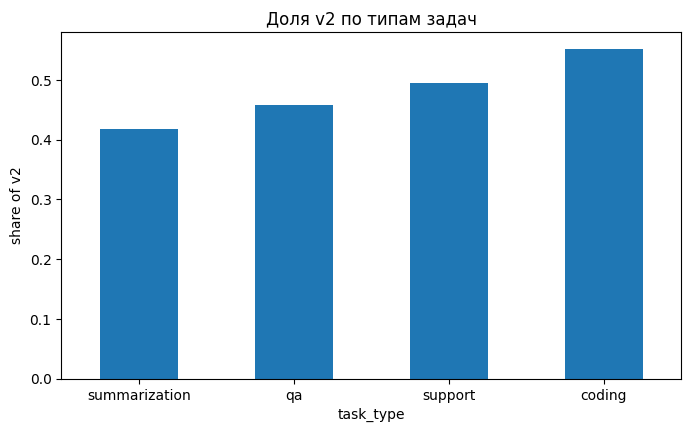

In [4]:
share_by_task = df.groupby("task_type")["is_v2"].mean().sort_values()

share_by_task.plot(kind="bar", rot=0)
plt.title("Доля v2 по типам задач")
plt.ylabel("share of v2")
plt.show()

Столбчатая диаграмма делает ту же мысль наглядной. По оси $x$ стоят типы задач, по оси $y$ — доля запросов, попавших на `v2` внутри каждого типа задачи. Если бы rollout был полностью равномерным, столбцы были бы примерно одинаковыми. Здесь они различаются, и это значит, что назначение в группу `v2` зависит от типа задачи. Уже на этом шаге ясно, почему дальше нужны контролирующие переменные.

Уже по этим таблицам видно, что `v2` живёт не в том же самом трафике, что и `v1`.  
Если доля `v2` различается по сегментам, то наивная разность средних перестаёт быть чистой оценкой эффекта версии модели.  
Она остаётся полезной как **описательная статистика**, но ещё не отвечает на вопрос «что происходит при прочих равных».

## Наивная разность средних

Пусть $Y_i$ — quality score запроса $i$.  
Если пока полностью забыть про остальные факторы и смотреть только на версию модели, естественная оценка — это

$$
\widehat{\Delta} = \bar Y_{v2} - \bar Y_{v1}.
$$

Для проверки гипотезы $H_0:\Delta=0$ можно использовать двухвыборочный t-критерий.  
В случае Welch t-test статистика имеет вид

$$
t = \frac{\bar Y_{v2} - \bar Y_{v1}}{\sqrt{s^2_{v2}/n_{v2} + s^2_{v1}/n_{v1}}}.
$$

Здесь $\bar Y_{v1}$ и $\bar Y_{v2}$ — выборочные средние `judge_score` в группах `v1` и `v2`,  
$s^2_{v1}$ и $s^2_{v2}$ — выборочные дисперсии в этих группах,  
$n_{v1}$ и $n_{v2}$ — размеры групп.

Эта процедура отвечает на очень простой вопрос: **различаются ли средние в двух наблюдаемых группах**.  
Но именно в такой постановке в неё не встроено ничего о сложности запроса, типе задачи, длине промпта и других факторах.

Поэтому первый шаг полезен, но его надо воспринимать как базовую отправную точку.


In [5]:
naive_diff = mean_diff_ttest(df, "judge_score")
display(naive_diff.round(4))

,control_mean,treatment_mean,difference,std_err,ci_low,ci_high,t_stat,p_value
judge_score,71.8201,73.8229,2.0028,0.1695,1.6706,2.3349,11.817,0.0


Эта таблица — результат функции `mean_diff_ttest`. В ней всего одна строка, потому что сейчас рассматривается только одна метрика — `judge_score`.

Столбцы читаются так.

* `control_mean` — средний `judge_score` для `v1`.
* `treatment_mean` — средний `judge_score` для `v2`.
* `difference` — оценка эффекта в самом наивном смысле, то есть $\bar Y_{v2} - \bar Y_{v1}$.
* `std_err` — стандартная ошибка этой разности.
* `ci_low`, `ci_high` — 95%-й доверительный интервал для разности средних.
* `t_stat` — статистика Welch t-test.
* `p_value` — p-value для проверки гипотезы о равенстве средних.

В текущем логе средний score у `v1` около $71.82$, у `v2` около $73.82$, а разность средних составляет примерно $2.00$ балла. Интервал лежит полностью выше нуля, поэтому статистически различие выглядит очень уверенным. Но пока это всё ещё различие в **наблюдаемом** трафике, а не «эффект `v2` при прочих равных».

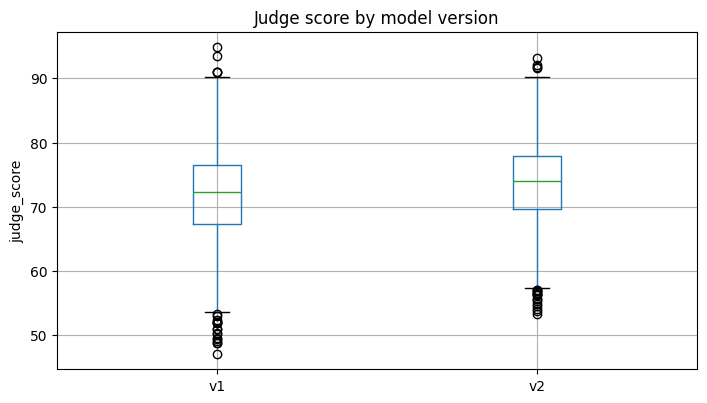

In [6]:
df.boxplot(column="judge_score", by="model_version")
plt.suptitle("")
plt.title("Judge score by model version")
plt.xlabel("")
plt.ylabel("judge_score")
plt.show()

На boxplot видно не только различие центров, но и разброс внутри групп. Среднее у `v2` выше, однако распределения заметно перекрываются. Это важное напоминание: статистически значимое различие средних не означает, что `v2` лучше на **каждом** отдельном запросе. Речь идёт о сдвиге среднего уровня, а не о полном доминировании одного распределения над другим.

Разность средних показывает, что в наблюдаемом трафике `v2` выглядит лучше.  
Однако дальше важно сделать следующий шаг: понять, что эта же самая задача естественно переписывается как **линейная регрессия**.

## Линейная регрессия: t-test и OLS

Рассмотрим модель

$$
Y_i = \beta_0 + \beta_1 D_i + \varepsilon_i,
$$

где в этом разделе $Y_i$ означает `judge_score`, а $D_i = 1$, если запрос обработан `v2`, и $D_i = 0$, если `v1`.  
Символ $\varepsilon_i$ обозначает ту часть `judge_score`, которую такая простая модель не объясняет.

Смысл коэффициентов здесь очень простой:

$$
\mathbb E[Y_i \mid D_i=0] = \beta_0, \qquad
\mathbb E[Y_i \mid D_i=1] = \beta_0 + \beta_1.
$$

Следовательно,

$$
\beta_1 = \mathbb E[Y_i \mid D_i=1] - \mathbb E[Y_i \mid D_i=0].
$$

Метод наименьших квадратов выбирает такие $\beta_0, \beta_1$, которые минимизируют сумму квадратов остатков:

$$
Q(\beta_0,\beta_1) = \sum_{i=1}^n (Y_i - \beta_0 - \beta_1 D_i)^2.
$$

Если $D_i$ бинарный, эту сумму удобно разложить по двум группам:

$$
Q(\beta_0,\beta_1)=
\sum_{D_i=0}(Y_i-\beta_0)^2 + \sum_{D_i=1}(Y_i-\beta_0-\beta_1)^2.
$$

Условия первого порядка дают

$$
\hat\beta_0 = \bar Y_{0}, \qquad
\hat\beta_1 = \bar Y_{1} - \bar Y_{0}.
$$

То есть в модели с одной бинарной регрессорной переменной **OLS буквально воспроизводит разность средних**.

В более общем виде OLS записывается через матрицу признаков $X$:

$$
\hat\beta = (X^\top X)^{-1}X^\top y.
$$

Здесь $X$ — матрица регрессоров, $y$ — вектор наблюдаемых значений отклика.  
Эта формула даёт геометрический смысл оценки: вектор наблюдений $y$ ортогонально проектируется на линейную оболочку столбцов $X$.  
Поэтому остатки $\hat\varepsilon = y - X\hat\beta$ удовлетворяют условию

$$
X^\top \hat\varepsilon = 0.
$$

Именно это условие лежит в основе большинства стандартных свойств OLS.


In [7]:
ols_simple = smf.ols("judge_score ~ is_v2", data=df).fit()

compare_naive_vs_ols = pd.DataFrame({
    "difference_in_means": [naive_diff.loc["judge_score", "difference"]],
    "ols_coef_is_v2": [ols_simple.params["is_v2"]],
    "ols_ci_low": [ols_simple.conf_int().loc["is_v2", 0]],
    "ols_ci_high": [ols_simple.conf_int().loc["is_v2", 1]],
    "ols_p_value": [ols_simple.pvalues["is_v2"]],
})

display(compare_naive_vs_ols.round(4))
display(coef_table(ols_simple).round(4))

,difference_in_means,ols_coef_is_v2,ols_ci_low,ols_ci_high,ols_p_value
0,2.0028,2.0028,1.6693,2.3362,0.0


,coef,std_err,ci_low,ci_high,p_value
Intercept,71.8201,0.1180,71.5887,72.0515,0.0
is_v2,2.0028,0.1701,1.6693,2.3362,0.0


Сейчас выведены две таблицы, и их полезно читать по отдельности.

Первая таблица `compare_naive_vs_ols` нужна для одного-единственного тезиса: в модели
$$
Y_i = \beta_0 + \beta_1 D_i + \varepsilon_i,
$$
где $Y_i$ — `judge_score`, а $D_i$ — индикатор `is_v2`, коэффициент при $D_i$ совпадает с наивной разностью средних. Поэтому в строке `difference_in_means` и в столбце `ols_coef_is_v2` стоят одни и те же числа. Эта таблица буквально показывает, что OLS с одной бинарной переменной — это тот же самый вопрос, что и t-test.

Вторая таблица `coef_table(ols_simple)` уже показывает параметры самой линейной модели.

* Строка `Intercept` — это $\hat\beta_0$. Поскольку `is_v2=0` соответствует `v1`, эта строка равна среднему quality score у `v1`. Здесь это примерно $71.82$.
* Строка `is_v2` — это $\hat\beta_1$. Она показывает, на сколько баллов меняется ожидаемый `judge_score`, если перейти от `v1` к `v2`. Здесь оценка около $2.00$.

Столбцы таблицы тоже имеют чёткий смысл.

* `coef` — численное значение оценки коэффициента.
* `std_err` — стандартная ошибка оценки.
* `ci_low`, `ci_high` — 95%-й доверительный интервал.
* `p_value` — p-value для проверки нулевой гипотезы, что соответствующий коэффициент равен нулю.

В этой простой модели строк всего две, и обе интерпретируются буквально. Чуть позже строк станет больше, и тогда именно такая табличная форма позволит не потеряться в смыслах.


Стандартная ошибка коэффициента $\hat\beta_1$ измеряет неопределённость в оценке разности между группами.  
Доверительный интервал строится как

$$
\hat\beta_1 \pm 1.96 \cdot \widehat{se}(\hat\beta_1),
$$

а Wald-статистика для проверки $H_0:\beta_1=0$ имеет вид

$$
t = \frac{\hat\beta_1}{\widehat{se}(\hat\beta_1)}.
$$


## Множественная линейная регрессия: эффект модели при прочих равных

Теперь пусть кроме версии модели у нас есть набор наблюдаемых факторов $Z_i$:  
тип задачи, язык, длина промпта, число документов в контексте, наличие tool use, cache hit и т.д.

В этом разделе $Y_i$ означает `judge_score`, $D_i$ — индикатор `is_v2`, а $Z_i$ — вектор контрольных переменных. Тогда естественная модель имеет вид

$$
Y_i = \beta_0 + \beta_1 D_i + \gamma^\top Z_i + \varepsilon_i.
$$

Здесь $\gamma$ — вектор коэффициентов при контрольных переменных, а $\varepsilon_i$ — остаток, который остаётся после учёта версии модели и контролей.

Коэффициент $\beta_1$ больше не читается как простая разность общих средних.  
Теперь он означает **условную разность средних** при фиксированных остальных переменных:

$$
\mathbb E[Y_i \mid D_i=1, Z_i] - \mathbb E[Y_i \mid D_i=0, Z_i] = \beta_1.
$$

Поскольку $D_i$ бинарен, здесь корректнее говорить именно о разности условных средних, а не о производной.

Если $D_i$ коррелирует с $Z_i$, а $Z_i$ влияет на $Y_i$, то наивная модель смешивает в одном числе два эффекта:

1. реальную связь между версией модели и качеством;
2. различие в составе трафика.

Это и есть интуиция omitted variable bias.

Очень полезный математический смысл даёт теорема Фриша–Во–Лавелла.  
Если регрессировать и отклик $Y$, и интересующий регрессор $D$ на контрольные переменные $Z$, а затем взять остатки $\widetilde Y$ и $\widetilde D$, то коэффициент при $D$ в полной модели можно записать как

$$
\hat\beta_1 = \frac{\widetilde D^\top \widetilde Y}{\widetilde D^\top \widetilde D}.
$$

То есть коэффициент при `v2` — это наклон в регрессии **остатка качества на остаток индикатора `is_v2`** после того, как из обоих вычли часть, объяснимую контролями.


In [8]:
controls_formula = (
    "judge_score ~ is_v2 + prompt_tokens + context_docs + has_tool + cache_hit "
    "+ C(task_type) + C(language) + C(user_tier) + C(prompt_template)"
)

ols_controls = smf.ols(controls_formula, data=df).fit()

controls_compare = pd.DataFrame({
    "model": ["naive", "with_controls"],
    "beta_is_v2": [ols_simple.params["is_v2"], ols_controls.params["is_v2"]],
    "std_err": [ols_simple.bse["is_v2"], ols_controls.bse["is_v2"]],
    "ci_low": [ols_simple.conf_int().loc["is_v2", 0], ols_controls.conf_int().loc["is_v2", 0]],
    "ci_high": [ols_simple.conf_int().loc["is_v2", 1], ols_controls.conf_int().loc["is_v2", 1]],
    "p_value": [ols_simple.pvalues["is_v2"], ols_controls.pvalues["is_v2"]],
    "R_squared": [ols_simple.rsquared, ols_controls.rsquared],
})

display(controls_compare.round(4))

key_terms = [
    "is_v2",
    "prompt_tokens",
    "context_docs",
    "has_tool",
    "cache_hit",
]
display(coef_table(ols_controls, terms=key_terms).round(4))

,model,beta_is_v2,std_err,ci_low,ci_high,p_value,R_squared
0,naive,2.0028,0.1701,1.6693,2.3362,0.0,0.0226
1,with_controls,2.1121,0.1279,1.8613,2.3629,0.0,0.4694


,coef,std_err,ci_low,ci_high,p_value
is_v2,2.1121,0.1279,1.8613,2.3629,0.0
prompt_tokens,-0.0035,0.0001,-0.0038,-0.0032,0.0
context_docs,-0.7101,0.0465,-0.8012,-0.6190,0.0
has_tool,-0.6904,0.1473,-0.9791,-0.4017,0.0
cache_hit,0.6342,0.1336,0.3723,0.8961,0.0


Здесь снова две таблицы, но теперь они уже отвечают на разные вопросы.

Первая таблица `controls_compare` сравнивает **две разные модели**.

* Строка `naive` — модель без controls, где есть только `is_v2`.
* Строка `with_controls` — модель, в которой кроме `is_v2` учитываются длина промпта, число документов, наличие tool use, cache hit, тип задачи, язык, тариф и prompt template.

В столбце `beta_is_v2` видно, как меняется оценка эффекта `v2`, когда мы переходим от наивного сравнения к сравнению «при прочих равных». Здесь коэффициент даже немного увеличивается: примерно с $2.00$ до $2.11$. Это означает, что состав трафика немного скрывал реальный выигрыш `v2` по качеству. Одновременно уменьшается `std_err`, а $R^2$ резко растёт. Последнее означает, что controls объясняют существенную часть вариации quality score.

Вторая таблица — это уже выборка **отдельных строк** из полной регрессионной таблицы `ols_controls`.

* `is_v2` — главный коэффициент интереса. Его интерпретация теперь такая: если взять два запроса одинаковой длины, с одинаковым числом документов, одинаковым типом задачи, языком, тарифом, шаблоном и состоянием кэша, то у `v2` ожидаемый `judge_score` примерно на $2.11$ балла выше.
* `prompt_tokens` — линейный эффект длины запроса. Оценка около $-0.0035$ на токен кажется маленькой, но это нормальная ситуация для переменной с большим масштабом. Удобнее читать её в более крупных единицах: дополнительные 1000 токенов дают примерно $-3.5$ балла качества.
* `context_docs` — изменение quality score при добавлении ещё одного документа в контекст. Здесь это примерно $-0.71$ балла на документ. Содержательно это означает, что более насыщенный контекст в этом synthetic-кейсе отражает более сложные запросы.
* `has_tool` — сдвиг относительно запросов без tool use. Отрицательный коэффициент около $-0.69$ говорит, что tool-queries в среднем труднее.
* `cache_hit` — сдвиг относительно cache miss. Положительный коэффициент около $+0.63$ означает, что запросы с cache hit в среднем связаны с немного более высоким quality score.

Если в полном summary модели встретятся строки вида `C(task_type)[T.qa]` или `C(language)[T.ru]`, их смысл тот же: это отклонения от базовой, не показанной в таблице категории. Для факторов всегда надо помнить, какая категория служит точкой отсчёта.

,full_model_coef_is_v2,fwl_coef_on_residualized_is_v2
0,2.1121,2.1121


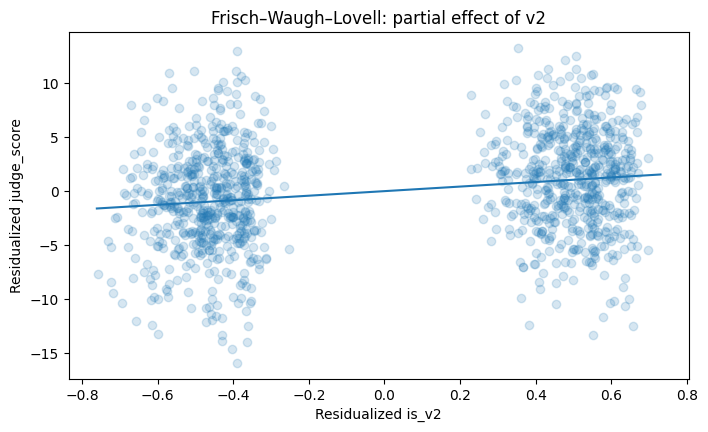

In [9]:
controls_only_formula = (
    "judge_score ~ prompt_tokens + context_docs + has_tool + cache_hit "
    "+ C(task_type) + C(language) + C(user_tier) + C(prompt_template)"
)

resid_y = smf.ols(controls_only_formula, data=df).fit().resid
resid_d = smf.ols(
    "is_v2 ~ prompt_tokens + context_docs + has_tool + cache_hit "
    "+ C(task_type) + C(language) + C(user_tier) + C(prompt_template)",
    data=df
).fit().resid
resid_d.name = "resid_d"

fwl_model = sm.OLS(resid_y, sm.add_constant(resid_d)).fit()

fwl_compare = pd.DataFrame({
    "full_model_coef_is_v2": [ols_controls.params["is_v2"]],
    "fwl_coef_on_residualized_is_v2": [fwl_model.params["resid_d"]],
})

display(fwl_compare.round(4))

sample_idx = np.random.default_rng(2026).choice(len(df), size=1200, replace=False)
plt.scatter(resid_d.iloc[sample_idx], resid_y.iloc[sample_idx], alpha=0.18)
x_line = np.linspace(resid_d.min(), resid_d.max(), 200)
y_line = fwl_model.params["const"] + fwl_model.params["resid_d"] * x_line
plt.plot(x_line, y_line)
plt.xlabel("Residualized is_v2")
plt.ylabel("Residualized judge_score")
plt.title("Frisch–Waugh–Lovell: partial effect of v2")
plt.show()

Таблица `fwl_compare` иллюстрирует теорему Фриша–Во–Лавелла буквально численно. В ней две строки-оценки одного и того же эффекта:

* `full_model_coef_is_v2` — коэффициент `is_v2` из полной регрессии с controls;
* `fwl_coef_on_residualized_is_v2` — коэффициент из регрессии остатка `judge_score` на остаток `is_v2` после вычитания controls.

Числа совпадают. Это и есть содержание теоремы: эффект `v2` можно оценивать либо в полной модели, либо после residualization обеих переменных по controls.

На диаграмме по оси $x$ стоит residualized `is_v2`, а по оси $y$ — residualized `judge_score`. Каждая точка — это уже не сырой запрос, а «то, что осталось» после вычитания объяснимой части, связанной с controls. Наклон прямой на таком графике и есть частный эффект `v2` при прочих равных. Геометрически это очень полезная картинка: она показывает, что множественная регрессия — это не магия, а аккуратное сравнение остатков после удаления влияния других факторов.

После добавления controls коэффициент при `v2` меняется, потому что теперь сравнение идёт **не между любыми запросами**, а между запросами сопоставимой сложности и структуры.

Именно поэтому в прикладных AI-задачах регрессия часто важнее, чем одиночный критерий:  
она позволяет отделить вопрос «новая модель лучше?» от вопроса «кому именно она чаще достаётся в трафике?».

Здесь полезно помнить, что высокий $R^2$ не является главной целью.  
Если нас интересует inference, то центральный объект — это не предсказание как таковое, а **коэффициент при интересующем факторе и его неопределённость**.

## Категориальные факторы, ANOVA и регрессия с фиктивными переменными

Когда фактор имеет больше двух уровней, естественно возникает ANOVA.  

Пусть $G_i \in \{1,\dots,k\}$ — категория, например один из $k$ prompt templates.  
Модель можно записать как

$$
Y_i = \mu + \alpha_{G_i} + \varepsilon_i,
\qquad \sum_{g=1}^k \alpha_g = 0,
$$

или эквивалентно как регрессию с $k-1$ фиктивными переменными.

Здесь $\mu$ — общее среднее по всем группам, $\alpha_g$ — отклонение среднего в группе $g$ от общего среднего, а $\varepsilon_i$ — внутригрупповой остаток.

В однофакторной ANOVA полная вариация раскладывается на межгрупповую и внутригрупповую:

$$
SST = SSB + SSW.
$$

Здесь

$$
SST = \sum_i (Y_i - \bar Y)^2,
\qquad
SSB = \sum_g n_g(\bar Y_g - \bar Y)^2,
\qquad
SSW = \sum_g \sum_{i \in g}(Y_i - \bar Y_g)^2.
$$

В этих обозначениях $\bar Y$ — общее выборочное среднее, $\bar Y_g$ — среднее внутри группы $g$, а $n_g$ — размер группы $g$.

F-статистика сравнивает объяснённую межгрупповую вариацию с остаточной:

$$
F = \frac{SSB/(k-1)}{SSW/(n-k)}.
$$

Если $F$ велико, нулевая гипотеза о равенстве всех групповых средних отвергается.  
Но это ещё не говорит, **какие именно** группы отличаются. Для этого после значимого omnibus-теста нужны post-hoc сравнения, например Tukey HSD.


In [10]:
template_eval = make_template_eval(seed=2026, n_per_template=180)

template_summary = (
    template_eval.groupby("template")["judge_score"]
    .agg(["mean", "std", "count"])
    .sort_values("mean")
)

display(template_summary.round(4))

,mean,std,count
template,,,
direct,74.2946,5.0435,180
fewshot,75.2163,4.4892,180
cot,76.0235,4.5259,180
structured,76.3865,4.6245,180


В таблице `template_summary` строки соответствуют четырём prompt templates.

* `mean` — средний `judge_score` в группе.
* `std` — стандартное отклонение внутри группы.
* `count` — размер группы.

Если читать строки сверху вниз, видно упорядочивание шаблонов по среднему качеству. В этом synthetic-примере `direct` выглядит слабее остальных, а `structured` — сильнее. Но сама по себе эта таблица ещё не говорит, какие различия статистически надёжны. Она только описывает групповые средние. Именно поэтому после неё идёт ANOVA и затем post-hoc сравнения.

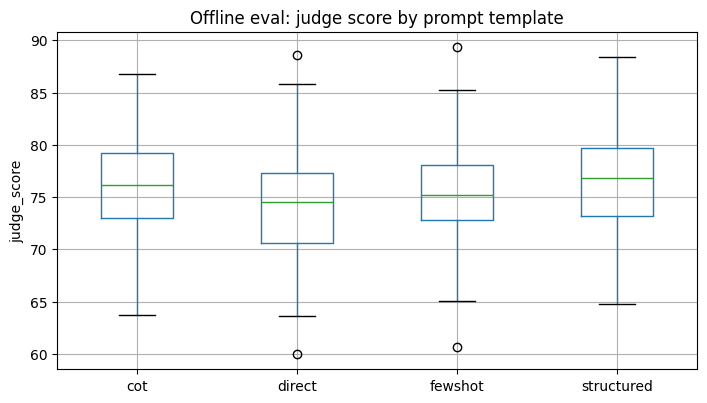

In [11]:
template_eval.boxplot(column="judge_score", by="template")
plt.suptitle("")
plt.title("Offline eval: judge score by prompt template")
plt.xlabel("")
plt.ylabel("judge_score")
plt.show()

In [12]:
anova_model = smf.ols("judge_score ~ C(template)", data=template_eval).fit()
anova_table = anova_lm(anova_model, typ=2)
display(anova_table.round(4))

tukey = pairwise_tukeyhsd(template_eval["judge_score"], template_eval["template"])
tukey_table = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)
display(tukey_table)

,sum_sq,df,F,PR(>F)
C(template),466.534,3.0,7.1123,0.0001
Residual,15655.417,716.0,NaN,NaN


,group1,group2,meandiff,p-adj,lower,upper,reject
0,cot,direct,-1.7289,0.0027,-2.9981,-0.4597,True
1,cot,fewshot,-0.8071,0.3581,-2.0764,0.4621,False
2,cot,structured,0.3630,0.8824,-0.9062,1.6323,False
3,direct,fewshot,0.9218,0.2419,-0.3475,2.1910,False
4,direct,structured,2.0919,0.0001,0.8227,3.3612,True
5,fewshot,structured,1.1702,0.0830,-0.0991,2.4394,False


В таблице `anova_table` строки интерпретируются так.

* `C(template)` — межгрупповая вариация, то есть та часть разброса `judge_score`, которую можно объяснить различием между prompt templates.
* `Residual` — внутригрупповая, необъяснённая вариация.

Столбцы имеют следующий смысл.

* `sum_sq` — сумма квадратов.
* `df` — число степеней свободы.
* `F` — F-статистика, сравнивающая межгрупповую и внутригрупповую вариацию.
* `PR(>F)` — p-value omnibus-теста.

Здесь $F\approx 7.11$ и p-value очень мало, поэтому глобальная гипотеза о равенстве всех четырёх средних отвергается. Но ANOVA не говорит, **какие именно** шаблоны отличаются. Для этого нужна вторая таблица — `tukey_table`.

В таблице Tukey каждая строка — это одна попарная проверка. Её удобно читать по шаблону `group2 - group1`.

* `group1`, `group2` — сравниваемые шаблоны.
* `meandiff` — разность средних `group2 - group1`.
* `p-adj` — p-value уже после поправки Tukey на множественные сравнения.
* `lower`, `upper` — доверительный интервал для разности.
* `reject` — отвергается ли гипотеза об отсутствии различия.

По строкам таблицы получается так:

* `cot` против `direct`: `direct` ниже `cot` примерно на $1.73$ балла; различие значимо.
* `cot` против `fewshot`: `fewshot` ниже `cot` примерно на $0.81$ балла; различие незначимо.
* `cot` против `structured`: `structured` чуть выше `cot`, но различие незначимо.
* `direct` против `fewshot`: `fewshot` выше `direct` примерно на $0.92$ балла; различие незначимо.
* `direct` против `structured`: `structured` выше `direct` примерно на $2.09$ балла; различие значимо.
* `fewshot` против `structured`: `structured` выше `fewshot` примерно на $1.17$ балла; интервал почти касается нуля, поэтому после поправки различие не подтверждается.

То есть тест говорит «хотя бы какие-то различия есть», а post-hoc показывает их конкретную структуру.

ANOVA отвечает на глобальный вопрос: **есть ли вообще различия между шаблонами**.  
Tukey HSD отвечает на следующий вопрос: **между какими именно парами есть значимая разница после поправки на множественные сравнения**.

С точки зрения регрессии это означает следующее.

* omnibus F-тест проверяет совместную гипотезу о нулевости всех коэффициентов при dummy-переменных;
* post-hoc contrasts проверяют линейные комбинации этих коэффициентов.

Такой взгляд очень полезен, потому что связывает в одну систему:
t-test, ANOVA, OLS и общую логику Wald/F/LR-тестов.

## Взаимодействия: когда один средний эффект скрывает сегментную неоднородность

Средний эффект часто удобен для первого описания, но в AI-продуктах он почти никогда не является единственной проверкой.  
Новая модель может особенно хорошо работать на `coding`, чуть хуже на `qa`, а на `support` почти не давать выигрыша.  
Аналогично, latency может расти вместе с длиной промпта по-разному для `v1` и `v2`.

Для непрерывной переменной $X_i$ модель с учетом взаимодействий имеет вид

$$
Y_i = \beta_0 + \beta_1 D_i + \beta_2 X_i + \beta_3(D_i X_i) + \varepsilon_i.
$$

Здесь $D_i$ — бинарный индикатор `v2`, $X_i$ — непрерывный фактор, например длина промпта, а $\beta_3$ — коэффициент interaction.

Тогда условный эффект `v2` при $X_i=x$ равен

$$
\mathbb E[Y_i \mid D_i=1, X_i=x] - \mathbb E[Y_i \mid D_i=0, X_i=x] = \beta_1 + \beta_3 x.
$$

Поскольку индикатор версии здесь бинарный, модель в этом месте корректнее рассматривать через условную разность, а не через производную.

Если $X_i$ центрировать, то $\beta_1$ становится эффектом `v2` в точке среднего значения $X$, а интерпретация становится заметно удобнее.

Для категориального сегмента $S_i$ взаимодействие означает, что эффект `v2` зависит от сегмента:

$$
Y_i = \beta_0 + \beta_1 D_i + \sum_s \alpha_s I(S_i=s)
+ \sum_s \delta_s D_i I(S_i=s) + \varepsilon_i.
$$

Здесь $I(S_i=s)$ — индикатор принадлежности к сегменту $s$, коэффициенты $\alpha_s$ описывают различия между сегментами сами по себе, а коэффициенты $\delta_s$ показывают, как именно в каждом сегменте меняется эффект `v2` относительно базового сегмента.

Именно такие модели нужны, когда команда решает, кому именно безопасно выкатывать новую версию.


In [13]:
interaction_quality = smf.ols(
    "judge_score ~ is_v2 * C(task_type) + prompt_tokens + context_docs + has_tool + cache_hit "
    "+ C(language) + C(user_tier) + C(prompt_template)",
    data=df
).fit()

task_effects = {
    "coding": linear_combo(interaction_quality, {"is_v2": 1}),
    "qa": linear_combo(interaction_quality, {"is_v2": 1, "is_v2:C(task_type)[T.qa]": 1}),
    "summarization": linear_combo(interaction_quality, {"is_v2": 1, "is_v2:C(task_type)[T.summarization]": 1}),
    "support": linear_combo(interaction_quality, {"is_v2": 1, "is_v2:C(task_type)[T.support]": 1}),
}
task_effects_table = pd.DataFrame(task_effects).T
display(task_effects_table.round(4))

,estimate,std_err,ci_low,ci_high,p_value
coding,4.4478,0.2475,3.9628,4.9328,0.0000
qa,1.5418,0.2144,1.1215,1.9621,0.0000
summarization,0.8621,0.2839,0.3056,1.4185,0.0024
support,1.3341,0.2757,0.7937,1.8746,0.0000


Таблица `task_effects_table` уже не показывает «сырые» коэффициенты модели. Она показывает **собранный эффект `v2` внутри каждого типа задачи**.

Строки таблицы — это сегменты `coding`, `qa`, `summarization`, `support`. Столбцы читаются стандартно:

* `estimate` — оценка эффекта `v2` в данном сегменте;
* `std_err` — стандартная ошибка этой сегментной оценки;
* `ci_low`, `ci_high` — 95%-й доверительный интервал;
* `p_value` — p-value для гипотезы, что сегментный эффект равен нулю.

Очень важно, что здесь каждая строка уже переведена на один и тот же смысловой язык: «на сколько баллов меняется `judge_score`, если в этом сегменте перейти от `v1` к `v2` при прочих равных». Поэтому строки можно сравнивать между собой напрямую.

Видно, что `coding` — это сегмент, где выигрыш `v2` особенно велик: около $+4.45$ балла. Для `qa` эффект заметно меньше, около $+1.54$ балла. Для `summarization` и `support` он тоже положителен, но слабее, чем в `coding`. Это и есть классический пример interaction effect: один и тот же rollout даёт разные выигрыши в разных задачах.

,v1,v2
task_type,,
coding,69.486,73.934
qa,75.139,76.681
summarization,77.657,78.519
support,79.442,80.776


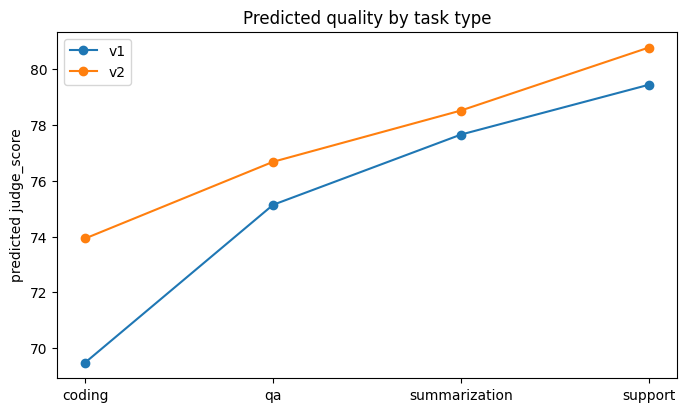

In [14]:
pred_grid = pd.DataFrame({
    "is_v2": np.repeat([0, 1], 4),
    "task_type": ["coding", "qa", "summarization", "support"] * 2,
    "prompt_tokens": df["prompt_tokens"].median(),
    "context_docs": df["context_docs"].median(),
    "has_tool": 0,
    "cache_hit": 1,
    "language": "en",
    "user_tier": "pro",
    "prompt_template": "structured",
})
pred_grid["predicted_judge_score"] = interaction_quality.predict(pred_grid)

pivot_pred = pred_grid.pivot(index="task_type", columns="is_v2", values="predicted_judge_score")
pivot_pred.columns = ["v1", "v2"]
display(pivot_pred.round(3))

x = np.arange(len(pivot_pred.index))
plt.plot(x, pivot_pred["v1"].values, marker="o", label="v1")
plt.plot(x, pivot_pred["v2"].values, marker="o", label="v2")
plt.xticks(x, pivot_pred.index, rotation=0)
plt.ylabel("predicted judge_score")
plt.title("Predicted quality by task type")
plt.legend()
plt.show()

Таблица `pivot_pred` переводит interaction-модель на язык предсказанных условных средних. Здесь строки — это типы задач, столбцы — версии модели `v1` и `v2`, а числа внутри — предсказанные значения `judge_score` для **одинакового репрезентативного запроса**: фиксированы медианная длина промпта, медианное число документов, `language='en'`, `user_tier='pro'`, `prompt_template='structured'` и отсутствие tool use.

Поэтому каждую строку можно читать буквально. Например, в строке `coding` модель прогнозирует около $69.49$ балла для `v1` и около $73.93$ для `v2`. Разность между столбцами внутри строки — это и есть условный выигрыш `v2` в данном сегменте. График рядом показывает то же самое визуально: линии не параллельны по смыслу, потому что выигрыш `v2` различается между задачами.

,coef,std_err,ci_low,ci_high,p_value
is_v2,14.1389,1.3228,11.5456,16.7321,0.0
prompt_tokens_c,0.0515,0.0018,0.0479,0.0550,0.0
is_v2:prompt_tokens_c,0.0124,0.0021,0.0083,0.0166,0.0


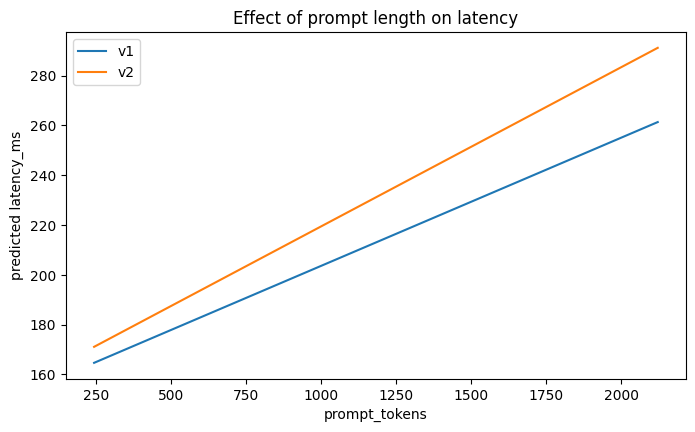

In [15]:
interaction_latency = smf.ols(
    "latency_ms ~ is_v2 * prompt_tokens_c + context_docs + has_tool + cache_hit "
    "+ C(task_type) + C(prompt_template)",
    data=df
).fit()

display(coef_table(interaction_latency, terms=["is_v2", "prompt_tokens_c", "is_v2:prompt_tokens_c"]).round(4))

grid = pd.DataFrame({
    "prompt_tokens_c": np.linspace(df["prompt_tokens_c"].quantile(0.05), df["prompt_tokens_c"].quantile(0.95), 100),
    "context_docs": df["context_docs"].median(),
    "has_tool": 0,
    "cache_hit": 1,
    "task_type": "qa",
    "prompt_template": "direct",
    "is_v2": 0,
})
pred_v1 = interaction_latency.predict(grid)

grid["is_v2"] = 1
pred_v2 = interaction_latency.predict(grid)

x_plot = grid["prompt_tokens_c"] + df["prompt_tokens"].mean()
plt.plot(x_plot, pred_v1, label="v1")
plt.plot(x_plot, pred_v2, label="v2")
plt.xlabel("prompt_tokens")
plt.ylabel("predicted latency_ms")
plt.title("Effect of prompt length on latency")
plt.legend()
plt.show()

В этой таблице показаны три ключевые строки модели `interaction_latency`.

* `is_v2` — эффект перехода на `v2` **при средней длине запроса**, потому что переменная `prompt_tokens_c` была предварительно центрирована. Здесь это примерно $+14.14$ мс.
* `prompt_tokens_c` — наклон latency по длине промпта для базовой модели `v1`. Оценка около $0.0515$ означает, что каждый дополнительный токен добавляет примерно $0.0515$ мс; то есть $+5.15$ мс на 100 токенов.
* `is_v2:prompt_tokens_c` — добавочный наклон для `v2` сверх наклона `v1`. Оценка около $0.0124$ означает, что у `v2` latency растёт с длиной запроса ещё быстрее.

Полный наклон для `v2` равен сумме двух последних строк:
$$
0.0515 + 0.0124 \approx 0.0639 \text{ мс на токен.}
$$
Значит, с ростом длины запроса разрыв между `v1` и `v2` увеличивается. Именно это и видно на графике: линии расходятся по мере роста `prompt_tokens`. В содержательном смысле это означает, что rollout `v2` особенно чувствителен к длинным запросам.

Средний коэффициент при `v2` может быть положительным, но это не означает, что он одинаков везде.

Взаимодействие помогает превратить один «средний lift» в карту сегментов:

* где `v2` действительно сильнее;
* где выигрыш минимален;
* где latency начинает расти особенно быстро;
* где rollout разумнее делать поэтапно, а не сразу на всех.

С практической точки зрения это уже **проектное решение, основанное на статистическом выводе**.

## Диагностика линейной модели: остатки, гетероскедастичность, влиятельные наблюдения

Линейная регрессия особенно полезна тогда, когда мы понимаем, **что именно делает модель и где она может ломаться**.

Для OLS центральны следующие объекты.

Остатки:

$$
e_i = y_i - \hat y_i.
$$

Здесь $y_i$ — наблюдаемое значение отклика, а $\hat y_i$ — значение, предсказанное моделью.

Матрица проекции (hat matrix):

$$
H = X(X^\top X)^{-1}X^\top,
\qquad h_{ii} = H_{ii}.
$$

Здесь $X$ — матрица регрессоров. Число $h_{ii}$ показывает leverage наблюдения: насколько сильно оно может тянуть гиперплоскость к себе просто за счёт положения в пространстве признаков.

Одной из популярных мер влияния является расстояние Кука:

$$
D_i = \frac{e_i^2}{p \hat\sigma^2}\cdot \frac{h_{ii}}{(1-h_{ii})^2},
$$

где $p$ — число оцениваемых параметров модели вместе с константой, а $\hat\sigma^2$ — оценка остаточной дисперсии. Большой $D_i$ указывает на то, что удаление наблюдения может заметно изменить коэффициенты.

Если дисперсия ошибок меняется от объекта к объекту, говорят о гетероскедастичности.  
Тогда OLS-коэффициенты могут оставаться полезными, но классические стандартные ошибки оказываются неверными.  
Один из популярных устойчивых вариантов — HC3-ковариационная матрица:

$$
\widehat{\mathrm{Var}}_{HC3}(\hat\beta) =
(X^\top X)^{-1} X^\top
\operatorname{diag}\!\left(\frac{e_i^2}{(1-h_{ii})^2}\right)
X (X^\top X)^{-1}.
$$

Для latency и cost такая диагностика особенно важна: эти метрики часто положительны, асимметричны и шумят всё сильнее по мере роста сложности запроса.


In [16]:
latency_formula = (
    "latency_ms ~ is_v2 + prompt_tokens_c + context_docs + has_tool + cache_hit "
    "+ C(task_type) + C(prompt_template)"
)

latency_plain = smf.ols(latency_formula, data=df).fit()
latency_hc3 = smf.ols(latency_formula, data=df).fit(cov_type="HC3")

se_compare = pd.DataFrame({
    "coef_is_v2": [latency_plain.params["is_v2"], latency_hc3.params["is_v2"]],
    "std_err_is_v2": [latency_plain.bse["is_v2"], latency_hc3.bse["is_v2"]],
    "ci_low": [latency_plain.conf_int().loc["is_v2", 0], latency_hc3.conf_int().loc["is_v2", 0]],
    "ci_high": [latency_plain.conf_int().loc["is_v2", 1], latency_hc3.conf_int().loc["is_v2", 1]],
    "p_value": [latency_plain.pvalues["is_v2"], latency_hc3.pvalues["is_v2"]],
}, index=["classical", "HC3"])

display(se_compare.round(4))

,coef_is_v2,std_err_is_v2,ci_low,ci_high,p_value
classical,14.111,1.3266,11.5104,16.7116,0.0
HC3,14.111,1.3284,11.5073,16.7147,0.0


Таблица `se_compare` сравнивает одну и ту же OLS-модель latency, но с двумя способами считать стандартные ошибки.

* Строка `classical` — обычные OLS-стандартные ошибки при предположении гомоскедастичности.
* Строка `HC3` — робастные стандартные ошибки, которые допускают гетероскедастичность.

Важно, что `coef_is_v2` в обеих строках одинаков. Это потому что changing covariance estimator меняет не оценку коэффициента, а только оценку его неопределённости. Поэтому дальше надо смотреть на `std_err_is_v2`, доверительный интервал и p-value. В текущем synthetic-примере разница между classical и HC3 небольшая, следовательно, вывод о положительном latency-эффекте `v2` устойчив. Но на реальных данных различие между этими двумя строками иногда оказывается очень заметным, и именно тогда HC3 становится принципиально важным.

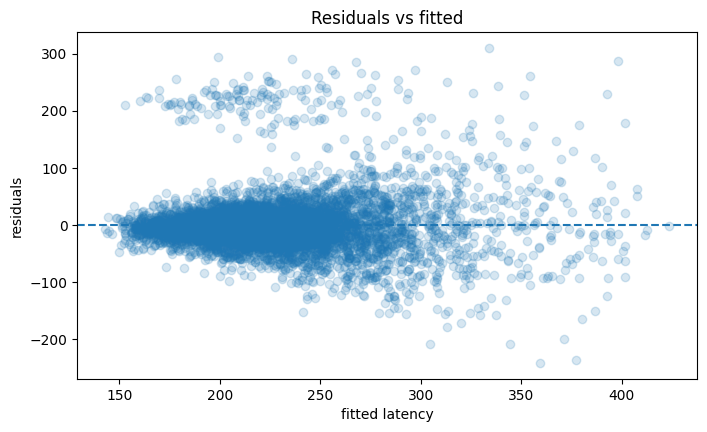

In [17]:
fitted = latency_plain.fittedvalues
resid = latency_plain.resid

plt.scatter(fitted, resid, alpha=0.18)
plt.axhline(0, linestyle="--")
plt.xlabel("fitted latency")
plt.ylabel("residuals")
plt.title("Residuals vs fitted")
plt.show()

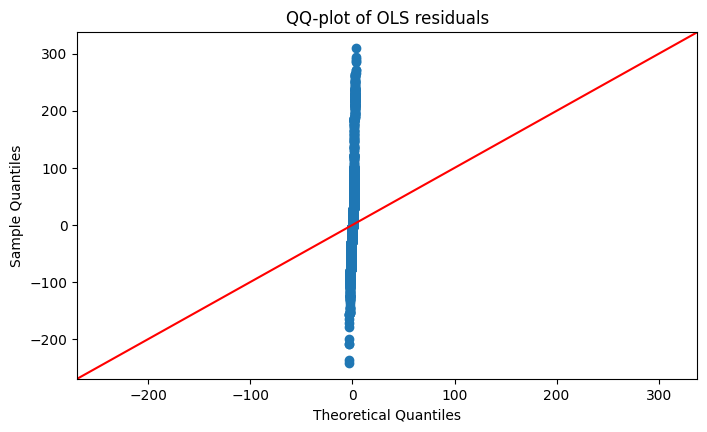

In [18]:
sm.qqplot(resid, line="45")
plt.title("QQ-plot of OLS residuals")
plt.show()

Два диагностических графика дополняют предыдущую таблицу.

На графике `Residuals vs fitted` по оси $x$ стоят предсказанные значения latency, а по оси $y$ — остатки. В идеальном линейном мире облако точек должно быть примерно одинаково широким по всей оси $x$ и не содержать выраженной структуры. Здесь видно, что по мере роста предсказанной latency разброс остатков увеличивается. Это типичный признак гетероскедастичности.

QQ-plot сравнивает эмпирические квантили остатков с нормальными. Если точки лежат на прямой, распределение остатков близко к нормальному. Отклонения в хвостах здесь вполне ожидаемы: latency чувствительна к cold starts, длинным запросам и другим инфраструктурным редкостям, поэтому распределение остатков здесь оказывается с более тяжёлыми хвостами, чем в идеальной гауссовой модели.

In [19]:
bp_lm, bp_lm_pvalue, bp_f, bp_f_pvalue = het_breuschpagan(resid, latency_plain.model.exog)
bp_table = pd.DataFrame({
    "Breusch_Pagan_LM": [bp_lm],
    "LM_p_value": [bp_lm_pvalue],
    "F_stat": [bp_f],
    "F_p_value": [bp_f_pvalue],
})
display(bp_table.round(4))

influence = OLSInfluence(latency_plain)
cooks_d = influence.cooks_distance[0]
leverage = influence.hat_matrix_diag

top_influential = (
    pd.DataFrame({
        "cooks_d": cooks_d,
        "leverage": leverage,
        "latency_ms": df["latency_ms"].values,
        "prompt_tokens": df["prompt_tokens"].values,
        "cold_start": df["cold_start"].values,
    })
    .sort_values("cooks_d", ascending=False)
    .head(10)
)

display(top_influential.round(4))

,Breusch_Pagan_LM,LM_p_value,F_stat,F_p_value
0,226.8507,0.0,21.3903,0.0


,cooks_d,leverage,latency_ms,prompt_tokens,cold_start
3832,0.0143,0.0053,685.7375,3500,0
3552,0.0103,0.0054,117.5028,3473,0
995,0.0100,0.0055,140.8320,3500,0
5532,0.0092,0.0030,643.9790,2442,1
624,0.0083,0.0049,621.8299,3500,0
2024,0.0075,0.0058,170.9299,3500,0
4279,0.0058,0.0026,615.9399,2693,1
692,0.0058,0.0058,553.8302,3500,0
2827,0.0056,0.0033,579.7227,2895,0
5734,0.0055,0.0021,552.9500,1656,1


После графиков идут уже численные диагностики.

Таблица `bp_table` — это результат теста Бройша–Пагана.

* `Breusch_Pagan_LM` и `F_stat` — две формы одной и той же идеи: проверить, зависит ли дисперсия остатков от регрессоров.
* `LM_p_value` и `F_p_value` — соответствующие p-value.

Здесь p-value практически нулевые, поэтому гипотеза о гомоскедастичности отвергается. Это хорошо согласуется с тем, что мы видели на графике остатков.

Вторая таблица `top_influential` устроена иначе: здесь строки — это не коэффициенты и не сегменты, а **конкретные наблюдения** с самым большим Cook's distance. По сути это список запросов, которые сильнее других влияют на оценку модели.

* `cooks_d` — насколько сильно наблюдение может сдвигать весь вектор коэффициентов.
* `leverage` — насколько экстремально положение наблюдения в пространстве признаков.
* `latency_ms`, `prompt_tokens`, `cold_start` — сами содержательные характеристики этого запроса.

Хорошо видно, что среди самых влиятельных точек часто встречаются очень длинные запросы и cold starts. Это ровно те случаи, которые и должны тянуть хвост latency-распределения.

In [20]:
X_vif = pd.DataFrame({
    "is_v2": df["is_v2"],
    "prompt_tokens_c": df["prompt_tokens_c"],
    "context_docs": df["context_docs"],
    "has_tool": df["has_tool"],
    "cache_hit": df["cache_hit"],
    "is_v2_x_prompt_tokens_c": df["is_v2"] * df["prompt_tokens_c"],
})
X_vif = sm.add_constant(X_vif)

vif_table = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
display(vif_table.round(4))

,variable,VIF
0,const,9.2653
1,is_v2,1.0064
2,prompt_tokens_c,2.0100
3,context_docs,1.1014
4,has_tool,1.0441
5,cache_hit,1.0302
6,is_v2_x_prompt_tokens_c,1.9329


Таблица `vif_table` нужна для диагностики мультиколлинеарности. Здесь каждая строка — один регрессор, а столбец `VIF` показывает, насколько дисперсия оценки этого коэффициента раздувается из-за линейной зависимости с другими регрессорами.

Важные правила чтения такие.

* `const` почти всегда имеет отдельное, малоинтересное значение и обычно не является предметом содержательной интерпретации.
* VIF, близкий к $1$, означает практически отсутствие проблемы.
* Большие VIF означают, что коэффициенты могут стать нестабильными и трудно интерпретируемыми.

В этой модели все содержательные VIF невелики. Это хороший знак: после центрирования `prompt_tokens_c` даже interaction-терм `is_v2_x_prompt_tokens_c` не создаёт серьёзной коллинеарности. Поэтому wide standard errors здесь объяснялись бы не дублированием признаков, а реальным шумом, а не геометрической неустойчивостью дизайна.

In [21]:
top_idx = np.argsort(cooks_d)[-20:]
df_sensitivity = df.drop(index=df.index[top_idx])

latency_refit = smf.ols(latency_formula, data=df_sensitivity).fit(cov_type="HC3")

sensitivity_compare = pd.DataFrame({
    "full_sample_coef_is_v2": [latency_hc3.params["is_v2"]],
    "trimmed_sample_coef_is_v2": [latency_refit.params["is_v2"]],
    "full_sample_se": [latency_hc3.bse["is_v2"]],
    "trimmed_sample_se": [latency_refit.bse["is_v2"]],
})
display(sensitivity_compare.round(4))

,full_sample_coef_is_v2,trimmed_sample_coef_is_v2,full_sample_se,trimmed_sample_se
0,14.111,14.139,1.3284,1.2792


Таблица `sensitivity_compare` — это sensitivity check. Она сравнивает коэффициент `is_v2` в latency-модели на полном наборе данных и после удаления 20 наблюдений с максимальным Cook's distance.

* `full_sample_coef_is_v2` — оценка на всей выборке.
* `trimmed_sample_coef_is_v2` — оценка после исключения наиболее влиятельных точек.
* `full_sample_se`, `trimmed_sample_se` — соответствующие стандартные ошибки.

Здесь коэффициент почти не меняется: около $14.11$ мс на полной выборке и около $14.14$ мс после trimming. Это означает, что вывод о том, что `v2` медленнее, не держится на нескольких экстремальных запросах. Для прикладной аналитики это очень ценная проверка: она показывает устойчивость вывода.

В этих диагностиках важно видеть не формальности, а смысл.

* `Residuals vs fitted` показывает, не осталось ли у модели явной структуры, которую линейная форма не поймала.
* QQ-plot помогает увидеть асимметрию и признаки распределения с тяжёлыми хвостами.
* Breusch–Pagan тестирует гетероскедастичность.
* Cook's distance показывает, насколько вывод зависит от нескольких особенно экстремальных точек.
* VIF измеряет, не «дублируют» ли признаки друг друга слишком сильно.

Практический вывод обычно такой: для latency полезно смотреть не только на коэффициенты, но и на **устойчивость inference**.  
Если HC3 заметно меняет стандартные ошибки или удаление нескольких точек двигает оценку, это уже важная часть интерпретации.

## Преобразования отклика: почему для стоимости часто удобнее логарифм

Для многих operational-метрик линейная модель на исходной шкале не является единственно разумной.  
Стоимость положительна, правосторонне скошена и часто ведёт себя мультипликативно: длиннее запрос часто означает не фиксированную прибавку в центах, а рост в процентах.

Классическое семейство преобразований Бокса–Кокса имеет вид

$$
g_\lambda(y)=
\begin{cases}
\dfrac{y^\lambda - 1}{\lambda}, & \lambda \neq 0, \\[6pt]
\log y, & \lambda = 0.
\end{cases}
$$

Здесь $\lambda$ — параметр преобразования. Логарифм — это предельный случай $\lambda \to 0$, и он особенно удобен, когда:

* отклик строго положителен;
* шум скорее относительный, чем абсолютный;
* нас интересуют **процентные**, а не только абсолютные изменения.

Пусть $C_i$ — стоимость запроса `cost_cents`, $D_i$ — индикатор `is_v2`, а $Z_i$ — вектор контрольных переменных. Если модель записана как

$$
\log C_i = \beta_0 + \beta_1 D_i + \gamma^\top Z_i + \varepsilon_i,
$$

то коэффициент $\beta_1$ прежде всего описывает сдвиг в условном среднем логарифма стоимости:

$$
\mathbb E[\log C_i \mid D_i=1, Z_i]
-
\mathbb E[\log C_i \mid D_i=0, Z_i]
=
\beta_1.
$$

Здесь $\gamma$ — вектор коэффициентов при контролях, а $\varepsilon_i$ — остаток.

Практически этот результат удобно переводить обратно на исходную шкалу через $\exp(\beta_1)$.  
В таком чтении $\exp(\beta_1)-1$ интерпретируют как приблизительное процентное изменение **типичного** уровня стоимости.  
Строго говоря, без дополнительных предположений это не точное утверждение про условное среднее $\mathbb E[C_i \mid X_i]$, а утверждение про лог-шкалу и геометрические средние. Но в прикладной аналитике именно такое приближённое чтение обычно и используют.


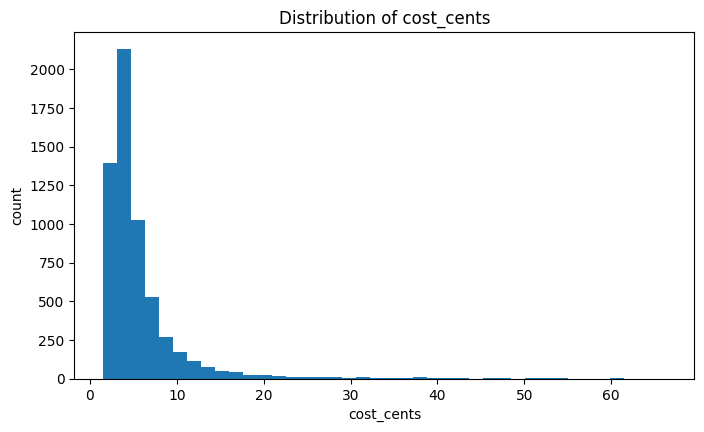

In [22]:
plt.hist(df["cost_cents"], bins=40)
plt.title("Distribution of cost_cents")
plt.xlabel("cost_cents")
plt.ylabel("count")
plt.show()

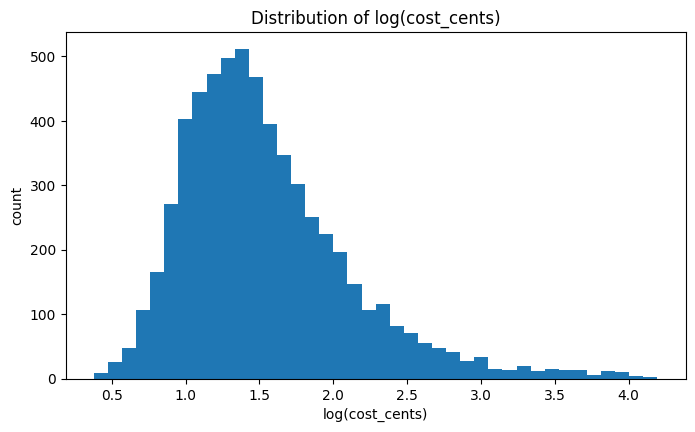

In [23]:
plt.hist(np.log(df["cost_cents"]), bins=40)
plt.title("Distribution of log(cost_cents)")
plt.xlabel("log(cost_cents)")
plt.ylabel("count")
plt.show()

Сравнение двух гистограмм показывает, зачем вообще понадобился логарифм. На исходной шкале `cost_cents` распределение заметно правосторонне скошено: длинный хвост дорогих запросов тянет массу вправо. После логарифмирования распределение становится значительно ближе к симметричному. Это не делает данные «идеально нормальными», но часто улучшает линейность и делает интерпретацию ближе к процентным изменениям, что для cost особенно естественно.

In [24]:
cost_formula = (
    "cost_cents ~ is_v2 + prompt_tokens + context_docs + has_tool + cache_hit "
    "+ C(task_type) + C(prompt_template) + C(user_tier)"
)

log_cost_formula = (
    "np.log(cost_cents) ~ is_v2 + prompt_tokens + context_docs + has_tool + cache_hit "
    "+ C(task_type) + C(prompt_template) + C(user_tier)"
)

cost_raw = smf.ols(cost_formula, data=df).fit(cov_type="HC3")
cost_log = smf.ols(log_cost_formula, data=df).fit(cov_type="HC3")

cost_compare = pd.DataFrame({
    "raw_scale_coef_is_v2": [cost_raw.params["is_v2"]],
    "raw_scale_ci_low": [cost_raw.conf_int().loc["is_v2", 0]],
    "raw_scale_ci_high": [cost_raw.conf_int().loc["is_v2", 1]],
    "log_scale_coef_is_v2": [cost_log.params["is_v2"]],
    "log_scale_ratio_exp_beta": [np.exp(cost_log.params["is_v2"])],
    "approx_percent_change": [100 * (np.exp(cost_log.params["is_v2"]) - 1)],
})
display(cost_compare.round(4))

,raw_scale_coef_is_v2,raw_scale_ci_low,raw_scale_ci_high,log_scale_coef_is_v2,log_scale_ratio_exp_beta,approx_percent_change
0,0.5913,0.4639,0.7186,0.1108,1.1172,11.716


Таблица `cost_compare` сопоставляет две модели стоимости — на исходной шкале и на лог-шкале.

В этой таблице одна строка, потому что нас интересует только коэффициент `is_v2`, но столбцы представляют два разных языка интерпретации.

* `raw_scale_coef_is_v2` — абсолютный эффект `v2` в центах. Здесь это примерно $+0.59$ цента на запрос.
* `raw_scale_ci_low`, `raw_scale_ci_high` — доверительный интервал для этого абсолютного эффекта.
* `log_scale_coef_is_v2` — коэффициент на шкале $\log C_i$, где $C_i$ обозначает `cost_cents`. Сам по себе он не очень удобен для менеджерского чтения.
* `log_scale_ratio_exp_beta` — экспонента лог-коэффициента. Именно она обычно и нужна: здесь $\exp(\hat\beta)\approx 1.117$.
* `approx_percent_change` — то же самое в процентной форме, примерно $+11.7\%$.

Последние два столбца удобно читать так: `v2` повышает **типичный уровень стоимости** примерно на $11.7\%$.  
Это практическое инженерное чтение лог-модели. Строже говоря, такая интерпретация относится к геометрическому среднему и к лог-шкале; для точного перехода к арифметическому среднему на исходной шкале потребовалась бы отдельная корректировка обратного преобразования.


На исходной шкале коэффициент показывает **абсолютный прирост стоимости** в центах.  
На лог-шкале тот же эффект читается как **приблизительный относительный рост типичного уровня стоимости**.

Для инженерных решений обе интерпретации полезны:

* абсолютная — когда важен прямой денежный эффект на запрос;
* относительная — когда надо сравнивать режимы на разных базовых уровнях стоимости.

Именно поэтому в прикладной аналитике cost и latency нередко рассматривают сразу в нескольких шкалах.


## GLM: общий мост от OLS к логиту и Пуассону

OLS — частный случай более общего семейства GLM.  
Обобщённая линейная модель (GLM) состоит из трёх частей.

1. **Распределение отклика** из экспоненциального семейства:

$$
f(y_i \mid \theta_i, \phi) =
\exp\left(
\frac{y_i\theta_i - b(\theta_i)}{a(\phi)} + c(y_i,\phi)
\right).
$$

Здесь $\theta_i$ — естественный параметр распределения, $\phi$ — параметр масштаба или дисперсии, а функции $a(\cdot)$, $b(\cdot)$ и $c(\cdot)$ задаются выбранным семейством распределений.

2. **Среднее** $\mu_i = \mathbb E[Y_i \mid X_i]$.

Здесь $\mu_i$ — условное среднее отклика.

3. **Функция связи** $g(\mu_i) = X_i^\top \beta$, которая делает линейный предиктор совместимым с природой отклика.

Здесь $g(\cdot)$ — функция связи, $X_i$ — вектор признаков, а $\beta$ — вектор регрессионных коэффициентов.

Для разных задач получаются разные частные случаи:

* Gaussian + identity link $\Rightarrow$ OLS;
* Bernoulli + logit link $\Rightarrow$ логистическая регрессия;
* Poisson + log link $\Rightarrow$ пуассоновская регрессия.

Главная идея GLM такова:  
мы моделируем **математическую связь между типом отклика, его средним и дисперсией**.


## Логистическая регрессия для бинарных AI-метрик

Пусть $G_i \in \{0,1\}$ — индикатор groundedness: $G_i=1$, если ответ опирается на предоставленный контекст, и $G_i=0$ иначе.  
Тогда естественно предположить

$$
G_i \sim \mathrm{Bernoulli}(p_i),
\qquad
\mathbb E[G_i \mid X_i] = p_i.
$$

Здесь $p_i$ — условная вероятность того, что ответ будет grounded.

Но $p_i$ должен лежать в $[0,1]$, и обычная линейная форма для среднего здесь неудобна.  
Поэтому используется логит-ссылка:

$$
\log\frac{p_i}{1-p_i} = X_i^\top \beta.
$$

Здесь $X_i$ — вектор признаков запроса, а $\beta$ — вектор коэффициентов.

Отсюда

$$
p_i = \frac{1}{1+\exp(-X_i^\top\beta)}.
$$

Лог-правдоподобие имеет вид

$$
\ell(\beta) = \sum_{i=1}^n
\left[
G_i \log p_i + (1-G_i)\log(1-p_i)
\right].
$$

Символ $\ell(\beta)$ обозначает логарифм функции правдоподобия. Максимизация $\ell(\beta)$ даёт оценку MLE.

Интерпретация коэффициента устроена иначе, чем в OLS.

* $\beta_j$ — изменение **логарифма отношения шансов**;
* $e^{\beta_j}$ — **отношение шансов**;
* marginal effects переводят логит-коэффициенты обратно на шкалу вероятностей.

Для AI-метрик это особенно важно, потому что `grounded`, `task_completed`, `policy_pass`, `tool_success` — естественно бинарные.


In [25]:
logit_grounded = smf.logit(
    "grounded ~ is_v2 + prompt_tokens + context_docs + has_tool + cache_hit "
    "+ C(language) + C(task_type) + C(prompt_template)",
    data=df
).fit(disp=False)

grounded_terms = ["is_v2", "prompt_tokens", "context_docs", "has_tool", "cache_hit"]
display(exp_table(logit_grounded, terms=grounded_terms, ratio_label="odds_ratio").round(4))

grounded_margeff = logit_grounded.get_margeff(at="overall")
grounded_margeff_table = grounded_margeff.summary_frame().loc[
    grounded_terms,
    ["dy/dx", "Std. Err.", "z", "Pr(>|z|)", "Conf. Int. Low", "Cont. Int. Hi."]
]
display(grounded_margeff_table.round(4))

,log_coef,odds_ratio,ci_low,ci_high,p_value
is_v2,0.3007,1.3508,1.2107,1.5071,0.0000
prompt_tokens,-0.0012,0.9988,0.9986,0.9990,0.0000
context_docs,-0.1726,0.8415,0.8085,0.8759,0.0000
has_tool,-0.2143,0.8071,0.7104,0.9170,0.0010
cache_hit,0.2000,1.2214,1.0889,1.3701,0.0006


,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
is_v2,0.0658,0.0121,5.4317,0.0000,0.0420,0.0895
prompt_tokens,-0.0003,0.0000,-16.2790,0.0000,-0.0003,-0.0002
context_docs,-0.0378,0.0044,-8.6414,0.0000,-0.0463,-0.0292
has_tool,-0.0469,0.0142,-3.3024,0.0010,-0.0747,-0.0191
cache_hit,0.0438,0.0128,3.4260,0.0006,0.0187,0.0688


Здесь выведены две таблицы для логит-модели `grounded`.

Первая таблица — это коэффициенты на логит-шкале и их экспоненты.

* `log_coef` — оценка $\hat\beta_j$ в уравнении log-odds.
* `odds_ratio` — величина $\exp(\hat\beta_j)$.
* `ci_low`, `ci_high` — доверительный интервал уже для odds ratio.
* `p_value` — проверка гипотезы, что соответствующий коэффициент равен нулю.

Как читать строки.

* `is_v2`: odds ratio около $1.35$. Это значит, что при прочих равных шансы на groundedness у `v2` примерно на $35\%$ выше, чем у `v1`.
* `prompt_tokens`: odds ratio чуть меньше единицы. На один токен эффект микроскопический, поэтому такую строку лучше читать на масштабе 100 токенов: длинные запросы заметно ухудшают groundedness.
* `context_docs`: odds ratio около $0.84$ на документ. Каждый дополнительный документ уменьшает шансы на groundedness примерно на $16\%$.
* `has_tool`: odds ratio около $0.81$. Запросы с tool use труднее удерживать grounded.
* `cache_hit`: odds ratio около $1.22$. Cache hit связан с более высокой groundedness.

Вторая таблица — это average marginal effects, то есть перевод логит-модели на шкалу вероятностей.

* `dy/dx` — средний предельный эффект на вероятность.
* `Std. Err.`, `z`, `Pr(>|z|)` — стандартная ошибка и статистика теста.
* `Conf. Int. Low`, `Cont. Int. Hi.` — доверительный интервал для предельного эффекта.

Здесь строки удобно читать так.

* `is_v2`: примерно $+0.0658$, то есть `v2` повышает вероятность groundedness примерно на $6.6$ процентного пункта в среднем по выборке.
* `prompt_tokens`: эффект отрицательный и маленький на один токен, поэтому его снова лучше агрегировать до 100 токенов.
* `context_docs`: примерно $-3.8$ п.п. на дополнительный документ.
* `has_tool`: примерно $-4.7$ п.п.
* `cache_hit`: примерно $+4.4$ п.п.

Главный смысл пары таблиц такой: odds ratios хороши для относительной интерпретации на шкале шансов, а marginal effects — для возвращения к интуитивной шкале вероятностей.

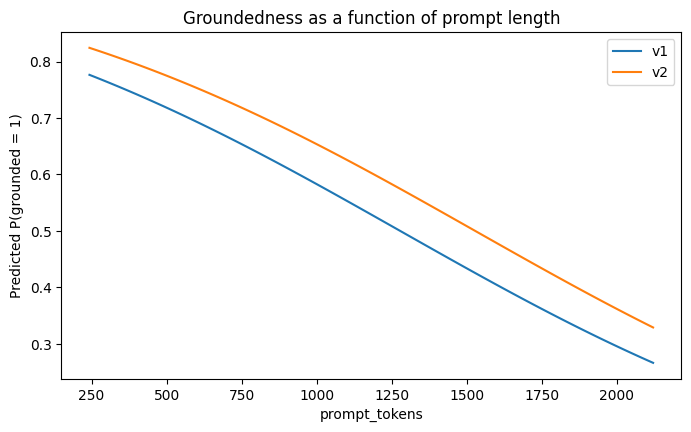

In [26]:
grid = pd.DataFrame({
    "is_v2": 0,
    "prompt_tokens": np.linspace(df["prompt_tokens"].quantile(0.05), df["prompt_tokens"].quantile(0.95), 100),
    "context_docs": df["context_docs"].median(),
    "has_tool": 0,
    "cache_hit": 1,
    "language": "en",
    "task_type": "qa",
    "prompt_template": "structured",
})
pred_ground_v1 = logit_grounded.predict(grid)

grid["is_v2"] = 1
pred_ground_v2 = logit_grounded.predict(grid)

x = grid["prompt_tokens"]
plt.plot(x, pred_ground_v1, label="v1")
plt.plot(x, pred_ground_v2, label="v2")
plt.xlabel("prompt_tokens")
plt.ylabel("Predicted P(grounded = 1)")
plt.title("Groundedness as a function of prompt length")
plt.legend()
plt.show()

График predicted probabilities надо читать аккуратно. По оси $x$ отложена длина промпта, а по оси $y$ — предсказанная вероятность того, что ответ будет grounded. Остальные признаки зафиксированы на типичном уровне: `language='en'`, `task_type='qa'`, `prompt_template='structured'`, `cache_hit=1`, `has_tool=0`.

Поэтому каждая линия — это не усреднение по всему трафику, а conditional curve для конкретного сценария. Видно две вещи одновременно: вероятность groundedness падает с ростом длины запроса, и при любой фиксированной длине `v2` лежит выше `v1`. Это полезный пример того, как логит-модель превращается из таблицы коэффициентов в содержательный operational-график.

Odds ratio полезен тем, что сразу показывает направление и относительный масштаб эффекта на шкале шансов.  
Но важно не перепутать odds ratio с разницей вероятностей.

Например, $e^{\beta}=1.30$ означает рост **шансов** в 1.3 раза, а не рост вероятности на 30 процентных пунктов.  
Чтобы вернуться к более интуитивной шкале, удобно смотреть либо predicted probabilities, либо average marginal effects.

В терминах AI-продукта такая модель отвечает на вопрос:

> как меняется вероятность того, что ответ будет grounded, если перейти от `v1` к `v2`, удерживая постоянными язык, тип задачи, длину промпта и другие факторы?

## Вложенные логит-модели и критерий отношения правдоподобия

Когда мы добавляем взаимодействие в логит-модель, возникает естественный вопрос:  
даёт ли это взаимодействие реальное улучшение модели или лишь усложняет запись?

Пусть есть две вложенные модели:
$$
\mathcal M_0 \subset \mathcal M_1.
$$

Здесь $\mathcal M_0$ — более простая модель, а $\mathcal M_1$ — расширенная модель, в которую добавлены interaction-термы.

Критерий отношения правдоподобия использует статистику

$$
LR = 2\bigl(\ell(\widehat\beta_1) - \ell(\widehat\beta_0)\bigr),
$$

где $\ell(\widehat\beta_0)$ и $\ell(\widehat\beta_1)$ — максимальные значения лог-правдоподобия в моделях $\mathcal M_0$ и $\mathcal M_1$ соответственно.

При нулевой гипотезе эта статистика асимптотически имеет распределение $\chi^2$ с числом степеней свободы, равным разности числа параметров в двух моделях.

Здесь мы проверим, нужна ли для `task_completed` неоднородность эффекта `v2` по типам задач.


In [27]:
logit_task_base = smf.logit(
    "task_completed ~ is_v2 + prompt_tokens + context_docs + has_tool + cache_hit "
    "+ C(language) + C(user_tier) + C(task_type) + C(prompt_template)",
    data=df
).fit(disp=False)

logit_task_inter = smf.logit(
    "task_completed ~ is_v2 * C(task_type) + prompt_tokens + context_docs + has_tool + cache_hit "
    "+ C(language) + C(user_tier) + C(prompt_template)",
    data=df
).fit(disp=False)

lr_stat = 2 * (logit_task_inter.llf - logit_task_base.llf)
df_diff = int(logit_task_inter.df_model - logit_task_base.df_model)
lr_pvalue = chi2.sf(lr_stat, df_diff)

lr_table = pd.DataFrame({
    "logLik_base": [logit_task_base.llf],
    "logLik_interaction": [logit_task_inter.llf],
    "LR_stat": [lr_stat],
    "df_diff": [df_diff],
    "p_value": [lr_pvalue],
})
display(lr_table.round(4))

task_terms = [name for name in logit_task_inter.params.index if "is_v2" in name]
display(exp_table(logit_task_inter, terms=task_terms, ratio_label="odds_ratio").round(4))

,logLik_base,logLik_interaction,LR_stat,df_diff,p_value
0,-3496.2117,-3477.3405,37.7423,3,0.0


,log_coef,odds_ratio,ci_low,ci_high,p_value
is_v2,1.0266,2.7914,2.1901,3.5579,0.0000
is_v2:C(task_type)[T.qa],-0.8261,0.4378,0.3211,0.5969,0.0000
is_v2:C(task_type)[T.summarization],-0.6223,0.5367,0.3721,0.7741,0.0009
is_v2:C(task_type)[T.support],-0.9390,0.3910,0.2796,0.5467,0.0000


И снова здесь выведены две таблицы с разным смыслом.

Первая таблица `lr_table` относится не к отдельным коэффициентам, а к сравнению **двух вложенных моделей**.

* `logLik_base` — максимум лог-правдоподобия базовой модели без interactions.
* `logLik_interaction` — максимум лог-правдоподобия модели с interactions.
* `LR_stat` — статистика критерия отношения правдоподобия.
* `df_diff` — насколько больше параметров в расширенной модели.
* `p_value` — ответ на вопрос, нужны ли interactions статистически.

Здесь p-value практически нулевой, значит, для `task_completed` неоднородность эффекта `v2` по типам задач реально важна.

Вторая таблица — это odds ratios interaction-модели. Здесь особенно важно помнить про базовую категорию фактора `task_type`. В `statsmodels` одна категория опускается и становится точкой отсчёта; в этой модели базовой оказывается `coding`. Поэтому строки читаются так.

* `is_v2` — эффект `v2` именно для базовой категории `coding`. Odds ratio около $2.79$ означает, что в `coding` шансы успешного завершения задачи у `v2` почти в 2.8 раза выше, чем у `v1`.
* `is_v2:C(task_type)[T.qa]` — поправка к этому эффекту для `qa`. Поскольку odds ratio здесь меньше единицы, выигрыш `v2` в `qa` существенно слабее, чем в `coding`.
* `is_v2:C(task_type)[T.summarization]` — аналогичная поправка для `summarization`.
* `is_v2:C(task_type)[T.support]` — поправка для `support`; она самая сильная по модулю, поэтому advantage `v2` в `support` почти исчезает.

Чтобы получить полный odds ratio в небазовом сегменте, надо сложить лог-коэффициенты или, что эквивалентно, перемножить odds ratios. Например,
$$
OR_{qa} = \exp(1.0266 - 0.8261) \approx 1.22,
$$
то есть в `qa` выигрыш `v2` сохраняется, но уже гораздо слабее, чем в `coding`.

Перед графиком полезно ввести ещё два термина.

**ROC-кривая** строится по всем возможным порогам вероятности и показывает компромисс между двумя долями:
- `true positive rate` — долей действительно успешных кейсов, которые модель правильно относит к успешным;
- `false positive rate` — долей действительно неуспешных кейсов, которые модель ошибочно относит к успешным.

**AUC** — площадь под ROC-кривой; она измеряет способность модели ранжировать успешные и неуспешные кейсы. Значение $0.5$ соответствует случайному ранжированию, а чем ближе AUC к $1$, тем лучше ранжирование.

Это уже язык prediction, а не интерпретации отдельных коэффициентов. Поэтому ROC/AUC здесь появляется как отдельная, дополнительная оптика на ту же самую логит-модель.


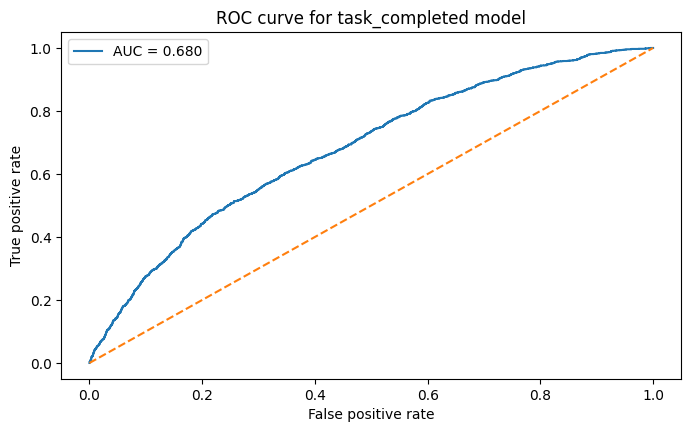

In [28]:
task_prob = logit_task_inter.predict(df)
auc = roc_auc_score(df["task_completed"], task_prob)

fpr, tpr, _ = roc_curve(df["task_completed"], task_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve for task_completed model")
plt.legend()
plt.show()

ROC-кривая отвечает не на вопрос об интерпретации коэффициентов, а на вопрос о качестве ранжирования. Каждая точка на ней соответствует некоторому порогу вероятности, а AUC показывает вероятность того, что модель присвоит более высокий score случайному успешному кейсу, чем случайному неуспешному. Хорошее AUC полезно для задач предсказания, но само по себе ничего не говорит ни о причинном эффекте, ни даже о частном условном эффекте `v2`. Поэтому ROC/AUC — это дополнение к анализу коэффициентов и статистической значимости, а не его замена.


Критерий отношения правдоподобия здесь отвечает на вопрос статистического вывода:  
нужны ли взаимодействия, чтобы адекватно описывать различие между задачами.

ROC/AUC отвечает на другой вопрос — насколько хорошо вероятностная модель **ранжирует** случаи по вероятности успеха.  
Это полезно, но не заменяет интерпретацию коэффициентов.

Именно поэтому для прикладной статистики важно разводить две оси:

* **статистический вывод** — что говорит коэффициент при интересующем факторе и насколько он устойчив;
* **предсказание** — насколько хорошо модель сортирует или предсказывает наблюдения.


## Пуассоновская регрессия: счётчики инцидентов и offset

Теперь перейдём к operational-метрикам уровня сервиса.  
Пусть $N_i$ — число timeout-событий за некоторый период. Счётчики принципиально отличаются от непрерывных откликов:

* они неотрицательны;
* часто имеют асимметричное распределение;
* естественно интерпретируются через интенсивность событий.

Пуассоновская модель задаёт

$$
N_i \sim \mathrm{Poisson}(\mu_i),
\qquad
\mathbb E[N_i \mid X_i] = \mu_i.
$$

Здесь $\mu_i$ — ожидаемое число событий в сегменте $i$, а $X_i$ — вектор признаков этого сегмента.

Для связи среднего с признаками используется лог-ссылка:

$$
\log \mu_i = X_i^\top \beta.
$$

Если периоды наблюдения или объём трафика различаются, надо учитывать **exposure**.  
Обозначим через $E_i$ объём трафика, например число запросов в сегменте. Тогда модель записывается как

$$
\log \mu_i = \log E_i + X_i^\top \beta,
$$

где $\log E_i$ добавляется как `offset`.

Это очень важный момент: без offset модель отвечает на плохой вопрос «кто имеет больше инцидентов вообще»,  
а с offset — на правильный вопрос «у кого выше **частота** инцидентов на единицу трафика».

Коэффициенты читаются через incidence rate ratio:

$$
IRR_j = e^{\beta_j}.
$$


In [29]:
ops_daily = (
    df.groupby(["date", "model_version", "task_type"], as_index=False)
      .agg(
          requests=("timeout_event", "size"),
          timeouts=("timeout_event", "sum"),
          mean_prompt_tokens=("prompt_tokens", "mean"),
          cold_start_share=("cold_start", "mean"),
      )
)

ops_daily["is_v2"] = (ops_daily["model_version"] == "v2").astype(int)

display(ops_daily.head())

,date,model_version,task_type,requests,timeouts,mean_prompt_tokens,cold_start_share,is_v2
0,2026-01-01,v1,coding,6,1,1438.3333,0.0000,0
1,2026-01-01,v1,qa,7,0,487.1429,0.0000,0
2,2026-01-01,v1,summarization,5,0,1000.6000,0.0000,0
3,2026-01-01,v1,support,3,0,316.3333,0.3333,0
4,2026-01-01,v2,coding,7,0,1326.4286,0.1429,1


Перед пуассоновской моделью лог преобразуется с уровня отдельных запросов на уровень агрегатов `date × model_version × task_type`. Поэтому таблица `ops_daily.head()` снова не содержит коэффициентов модели — она показывает агрегированные operational-наблюдения.

Каждая строка — это один день, одна версия модели и один тип задачи. Столбцы читаются так.

* `requests` — сколько запросов было в этом сегменте за день.
* `timeouts` — сколько из них завершились таймаутом.
* `mean_prompt_tokens` — средняя длина промпта в этом сегменте.
* `cold_start_share` — доля cold starts.
* `is_v2` — индикатор версии модели.

Именно `requests` потом станет exposure и войдёт в модель как `offset`. Мы хотим сравнивать не сырое число таймаутов, а timeout-rate на единицу трафика.

In [30]:
poisson_timeouts = smf.glm(
    "timeouts ~ is_v2 + mean_prompt_tokens + cold_start_share + C(task_type)",
    data=ops_daily,
    family=sm.families.Poisson(),
    offset=np.log(ops_daily["requests"])
).fit()

display(exp_table(poisson_timeouts, ratio_label="IRR").round(4))

,log_coef,IRR,ci_low,ci_high,p_value
Intercept,-4.4313,0.0119,0.0060,0.0235,0.0000
C(task_type)[T.qa],-0.0604,0.9414,0.5646,1.5697,0.8170
C(task_type)[T.summarization],-0.2331,0.7921,0.5630,1.1143,0.1807
C(task_type)[T.support],-0.2280,0.7961,0.4136,1.5323,0.4949
is_v2,0.3860,1.4711,1.1808,1.8328,0.0006
mean_prompt_tokens,0.0013,1.0013,1.0009,1.0017,0.0000
cold_start_share,1.4471,4.2508,1.2637,14.2991,0.0194


В таблице пуассоновской модели строки — это коэффициенты лог-rate-модели, а столбцы уже специально переведены на язык incidence rate ratios.

* `log_coef` — коэффициент на шкале $\log(\mu)$.
* `IRR` — величина $\exp(\hat\beta)$, то есть multiplicative effect на rate.
* `ci_low`, `ci_high` — доверительный интервал для IRR.
* `p_value` — проверка нулевой гипотезы об отсутствии эффекта.

Как читать строки.

* `Intercept` — базовый timeout-rate для опущенной категории `task_type` при нулевых значениях числовых регрессоров. Обычно это техническая строка, а не главный предмет содержательного обсуждения.
* `C(task_type)[T.qa]`, `C(task_type)[T.summarization]`, `C(task_type)[T.support]` — различие в timeout-rate относительно базового `task_type`. Здесь интервалы содержат единицу, значит, после учёта остальных факторов сильных отличий не видно.
* `is_v2`: $IRR\approx 1.47$. Это означает, что timeout-rate у `v2` примерно на $47\%$ выше, чем у `v1`, при одинаковом трафике, средней длине промпта и доле cold starts.
* `mean_prompt_tokens`: $IRR\approx 1.0013$ на токен. Как и раньше, удобнее читать это на масштабе 100 токенов: примерно $\exp(0.0013\cdot 100)\approx 1.14$, то есть около $14\%$ роста timeout-rate на каждые 100 дополнительных токенов.
* `cold_start_share`: $IRR\approx 4.25$. Сегменты с большим числом cold starts имеют резко повышенную интенсивность таймаутов.

Это хороший пример того, что для operational-метрик count-модели часто оказываются естественнее, чем OLS.

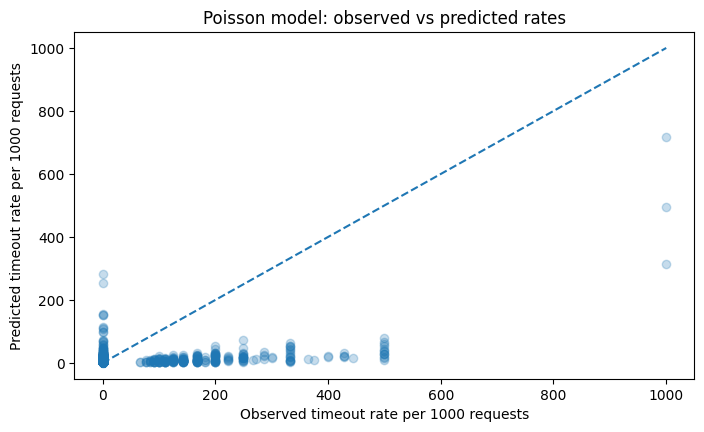

In [31]:
ops_daily["pred_timeouts"] = poisson_timeouts.predict(ops_daily)
ops_daily["observed_rate_per_1000"] = 1000 * ops_daily["timeouts"] / ops_daily["requests"]
ops_daily["predicted_rate_per_1000"] = 1000 * ops_daily["pred_timeouts"] / ops_daily["requests"]

plt.scatter(ops_daily["observed_rate_per_1000"], ops_daily["predicted_rate_per_1000"], alpha=0.25)
line_min = min(ops_daily["observed_rate_per_1000"].min(), ops_daily["predicted_rate_per_1000"].min())
line_max = max(ops_daily["observed_rate_per_1000"].max(), ops_daily["predicted_rate_per_1000"].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")
plt.xlabel("Observed timeout rate per 1000 requests")
plt.ylabel("Predicted timeout rate per 1000 requests")
plt.title("Poisson model: observed vs predicted rates")
plt.show()

Если $IRR>1$, то соответствующий фактор увеличивает интенсивность инцидентов; если $IRR<1$, уменьшает её.  
Это удобно для LLMOps и agent-ops, где нас интересуют retry-rate, error-rate, timeout-rate и прочие operational counts.

Для полноты картины важно помнить, что у реальных счётчиков дисперсия часто превышает среднее.  
Тогда стоит думать об overdispersion и о переходе к quasi-Poisson или Negative Binomial.  
Но как первая модель для rate-метрик Poisson с offset — почти обязательный инструмент.

## Финальная сводка: что статистика говорит про rollout `v2`

Хорошая прикладная модель не заканчивается p-value.  
Она должна помогать принять решение. Ниже соберём вместе несколько ключевых эффектов на шкалах, удобных для чтения.

In [32]:
summary_rows = []

# judge_score: OLS with controls
ci = ols_controls.conf_int().loc["is_v2"]
summary_rows.append({
    "metric": "judge_score",
    "model": "OLS with controls",
    "effect_of_v2": ols_controls.params["is_v2"],
    "ci": f"[{ci[0]:.3f}; {ci[1]:.3f}]",
    "interpretation": "изменение quality score в баллах при прочих равных",
})

# latency at mean prompt length
ci = latency_hc3.conf_int().loc["is_v2"]
summary_rows.append({
    "metric": "latency_ms",
    "model": "OLS HC3",
    "effect_of_v2": latency_hc3.params["is_v2"],
    "ci": f"[{ci[0]:.3f}; {ci[1]:.3f}]",
    "interpretation": "добавка к latency в мс при среднем prompt_tokens",
})

# cost on log scale
ci = cost_log.conf_int().loc["is_v2"]
summary_rows.append({
    "metric": "cost_cents",
    "model": "log-OLS HC3",
    "effect_of_v2": np.exp(cost_log.params["is_v2"]),
    "ci": f"[{np.exp(ci[0]):.3f}; {np.exp(ci[1]):.3f}]",
    "interpretation": "мультипликативный эффект на cost, exp(beta)",
})

# grounded
ci = logit_grounded.conf_int().loc["is_v2"]
summary_rows.append({
    "metric": "grounded",
    "model": "Logit",
    "effect_of_v2": np.exp(logit_grounded.params["is_v2"]),
    "ci": f"[{np.exp(ci[0]):.3f}; {np.exp(ci[1]):.3f}]",
    "interpretation": "odds ratio groundedness для v2",
})

# task_completed
ci = logit_task_inter.conf_int().loc["is_v2"]
summary_rows.append({
    "metric": "task_completed (baseline task)",
    "model": "Logit with interaction",
    "effect_of_v2": np.exp(logit_task_inter.params["is_v2"]),
    "ci": f"[{np.exp(ci[0]):.3f}; {np.exp(ci[1]):.3f}]",
    "interpretation": "odds ratio для базового task_type",
})

# timeouts
ci = poisson_timeouts.conf_int().loc["is_v2"]
summary_rows.append({
    "metric": "timeouts per request",
    "model": "Poisson with offset",
    "effect_of_v2": np.exp(poisson_timeouts.params["is_v2"]),
    "ci": f"[{np.exp(ci[0]):.3f}; {np.exp(ci[1]):.3f}]",
    "interpretation": "incidence rate ratio timeout-rate для v2",
})

rollout_summary = pd.DataFrame(summary_rows)
display(rollout_summary.round(4))

,metric,model,effect_of_v2,ci,interpretation
0,judge_score,OLS with controls,2.1121,[1.861; 2.363],изменение quality score в баллах при прочих ра...
1,latency_ms,OLS HC3,14.1110,[11.507; 16.715],добавка к latency в мс при среднем prompt_tokens
2,cost_cents,log-OLS HC3,1.1172,[1.110; 1.124],"мультипликативный эффект на cost, exp(beta)"
3,grounded,Logit,1.3508,[1.211; 1.507],odds ratio groundedness для v2
4,task_completed (baseline task),Logit with interaction,2.7914,[2.190; 3.558],odds ratio для базового task_type
5,timeouts per request,Poisson with offset,1.4711,[1.181; 1.833],incidence rate ratio timeout-rate для v2


Итоговую таблицу `rollout_summary` полезно читать построчно, но при этом помнить, что строки измеряются на **разных шкалах** и поэтому их нельзя сравнивать по величине числа.

* `judge_score`, модель `OLS with controls`: `effect_of_v2` около $+2.11$. Это означает прибавку примерно в $2.11$ балла качества при прочих равных.
* `latency_ms`, модель `OLS HC3`: `effect_of_v2` около $+14.11$ мс. Это добавка к latency при средней длине запроса.
* `cost_cents`, модель `log-OLS HC3`: `effect_of_v2` около $1.117$. Это не центы, а multiplicative factor; его надо читать как рост стоимости примерно на $11.7\%$.
* `grounded`, модель `Logit`: `effect_of_v2` около $1.351$. Это odds ratio groundedness, то есть рост шансов быть grounded примерно на $35\%$.
* `task_completed (baseline task)`, модель `Logit with interaction`: `effect_of_v2` около $2.79$. Это odds ratio именно для базового типа задачи (`coding`). Для других задач надо учитывать interaction-коэффициенты из предыдущего раздела.
* `timeouts per request`, модель `Poisson with offset`: `effect_of_v2` около $1.47$. Это incidence rate ratio, то есть timeout-rate у `v2` выше примерно на $47\%$.

Столбец `ci` везде даёт доверительный интервал, но его тоже надо читать на той шкале, на которой записан эффект: для OLS это аддитивная шкала, для логита и Пуассона — мультипликативная. Столбец `interpretation` специально напоминает, какой именно язык применим к каждой строке.

Если собрать всё вместе, получается не бинарный ответ «хорошая модель» или «плохая модель», а trade-off: `v2` улучшает качество и completion, но платит за это latency, cost и timeout-rate. Именно такой формат вывода и нужен реальной AI-команде перед rollout-решением.

Если читать все модели вместе, то получается типичная для индустрии ИИ картина.

* `v2` улучшает quality metrics и повышает вероятность успешного выполнения задачи.
* Выигрыш неравномерен: в одних сегментах он заметнее, чем в других.
* Одновременно `v2` дороже и медленнее, особенно на длинных запросах.
* С операционной точки зрения это может сопровождаться ростом частоты некоторых инцидентов.

Значит, разумное решение часто выглядит не как «сразу выкатить всем», а как **segmented rollout**:

* сначала на сильные сегменты;
* потом на часть трафика;
* с мониторингом latency/cost/error-rate;
* с fallback-политикой там, где взаимодействия показывают риск.

Именно в этом и состоит прикладной смысл регрессии для AI-команд:  
она превращает хаотический набор метрик в связный язык инженерного решения.

Последний важный вывод такой.  
Даже очень хорошая регрессионная модель на логах бета-роллаута автоматически не говорит о наличие причинного эффекта.
Чтобы из связи перейти к эффекту rollout, нужен следующий шаг — дизайн эксперимента, контроль смешения и каузальный анализ.